# 1. Introdução
Este projeto visa analisar e prever a evolução das temperaturas médias globais e regionais ao longo dos anos,
utilizando dados históricos fornecidos pela FAO (Food and Agriculture Organization). O foco principal é construir
um modelo de Machine Learning capaz de prever o crescimento da temperatura média para países e regiões específicas
(Brasil, países do G7 e a média mundial) em horizontes de tempo de 5, 10 e 50 anos no futuro.

A compreensão e previsão do aquecimento global são cruciais para informar políticas climáticas, auxiliar no
planejamento estratégico de nações e organizações, e identificar os fatores mais influentes nas mudanças de temperatura.

Esta primeira parte do notebook concentra-se na coleta, descrição e análise exploratória detalhada dos dados de temperatura,
incluindo o tratamento inicial e visualizações para extrair insights sobre as tendências históricas e a distribuição das mudanças
de temperatura por região.


### 1.1 Importações

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display


# 2. Coleta e descrição dos dados

### 2.1 Temperatura

Dataset de temperatura carregado com sucesso!

--- Dataset após 'melt' e renomeação de colunas ---


,Area Code,Country,Months Code,Months,Element Code,Element,Unit,Year,Temperature_Change
0,2,Afghanistan,7001,January,7271,Temperature change,°C,1961,0.777
1,2,Afghanistan,7001,January,6078,Standard Deviation,°C,1961,1.950
2,2,Afghanistan,7002,February,7271,Temperature change,°C,1961,-1.743
3,2,Afghanistan,7002,February,6078,Standard Deviation,°C,1961,2.597
4,2,Afghanistan,7003,March,7271,Temperature change,°C,1961,0.516


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569704 entries, 0 to 569703
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Area Code           569704 non-null  int64  
 1   Country             569704 non-null  object 
 2   Months Code         569704 non-null  int64  
 3   Months              569704 non-null  object 
 4   Element Code        569704 non-null  int64  
 5   Element             569704 non-null  object 
 6   Unit                569704 non-null  object 
 7   Year                569704 non-null  int32  
 8   Temperature_Change  491601 non-null  float64
dtypes: float64(1), int32(1), int64(3), object(4)
memory usage: 36.9+ MB
None

--- Valores únicos na coluna 'Element' ---
['Temperature change' 'Standard Deviation']

--- Dataset de temperatura anual médio por região (9 regiões) ---


,Country,Year,Temperature_Change
0,Brazil,1961,0.154824
1,Brazil,1962,-0.176706
2,Brazil,1963,0.157824
3,Brazil,1964,-0.268824
4,Brazil,1965,-0.028059


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 10.5+ KB
None

--- Estatísticas descritivas da Mudança de Temperatura por País/Região ---


,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Brazil,59.0,0.551051,0.533317,-0.377529,0.153618,0.478588,0.964735,1.752118
Canada,59.0,0.603377,0.901940,-1.849941,-0.001294,0.520882,1.114941,3.033412
France,59.0,0.660753,0.755796,-0.942118,-0.000265,0.695588,1.281765,2.138824
Germany,59.0,0.699176,0.894596,-1.079647,-0.054971,0.808882,1.434471,2.461588
Italy,59.0,0.585374,0.684581,-0.601706,-0.004794,0.486588,1.141912,1.921353
Japan,59.0,0.319842,0.516491,-0.591235,-0.037353,0.320706,0.667647,1.266000
United Kingdom,59.0,0.414684,0.607859,-0.855824,-0.061441,0.429882,0.980441,1.639765
United States of America,59.0,0.448604,0.564611,-0.386176,-0.014853,0.396529,0.878588,2.039647
World,59.0,0.524768,0.514660,-0.297412,0.093941,0.438412,0.957529,1.626059



--- Gerando visualizações para análise de tendências e distribuições ---


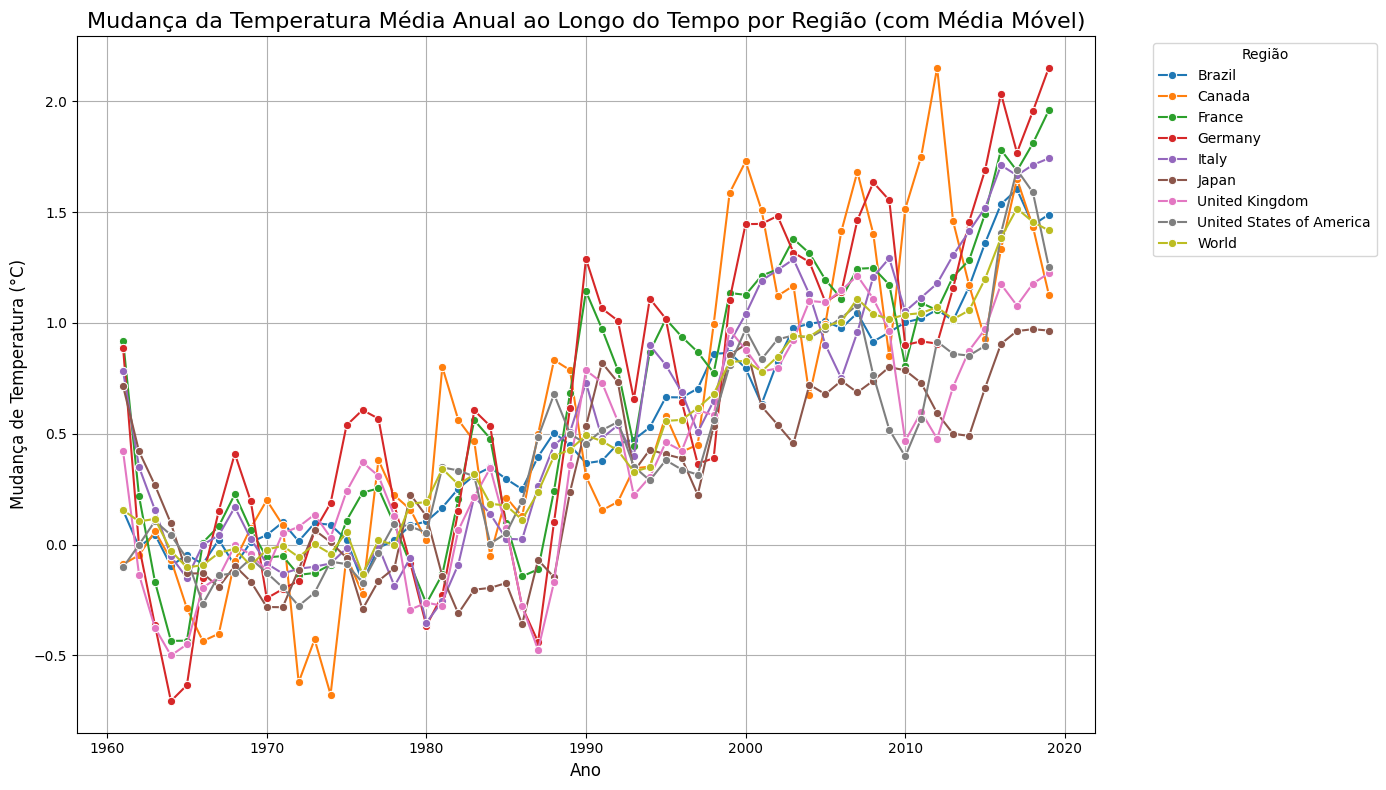

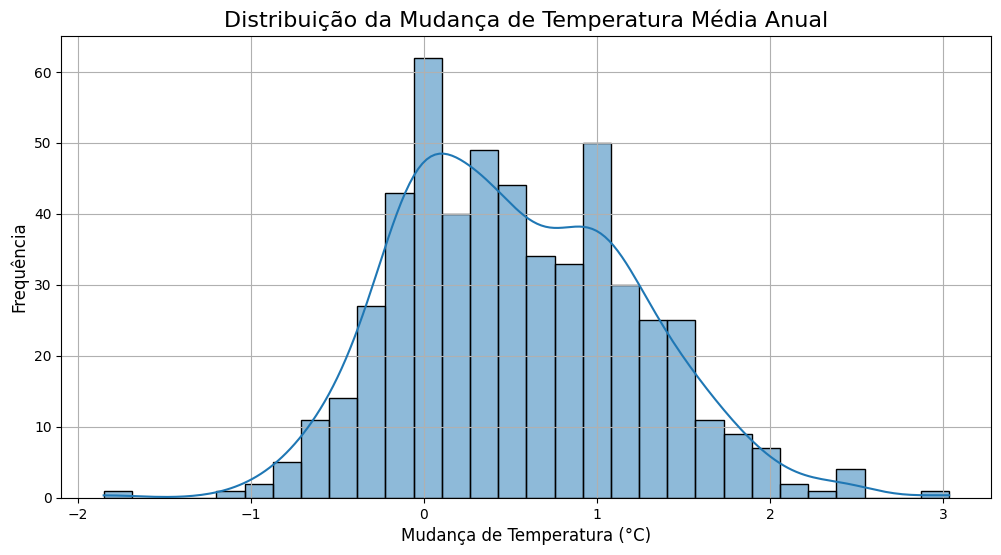

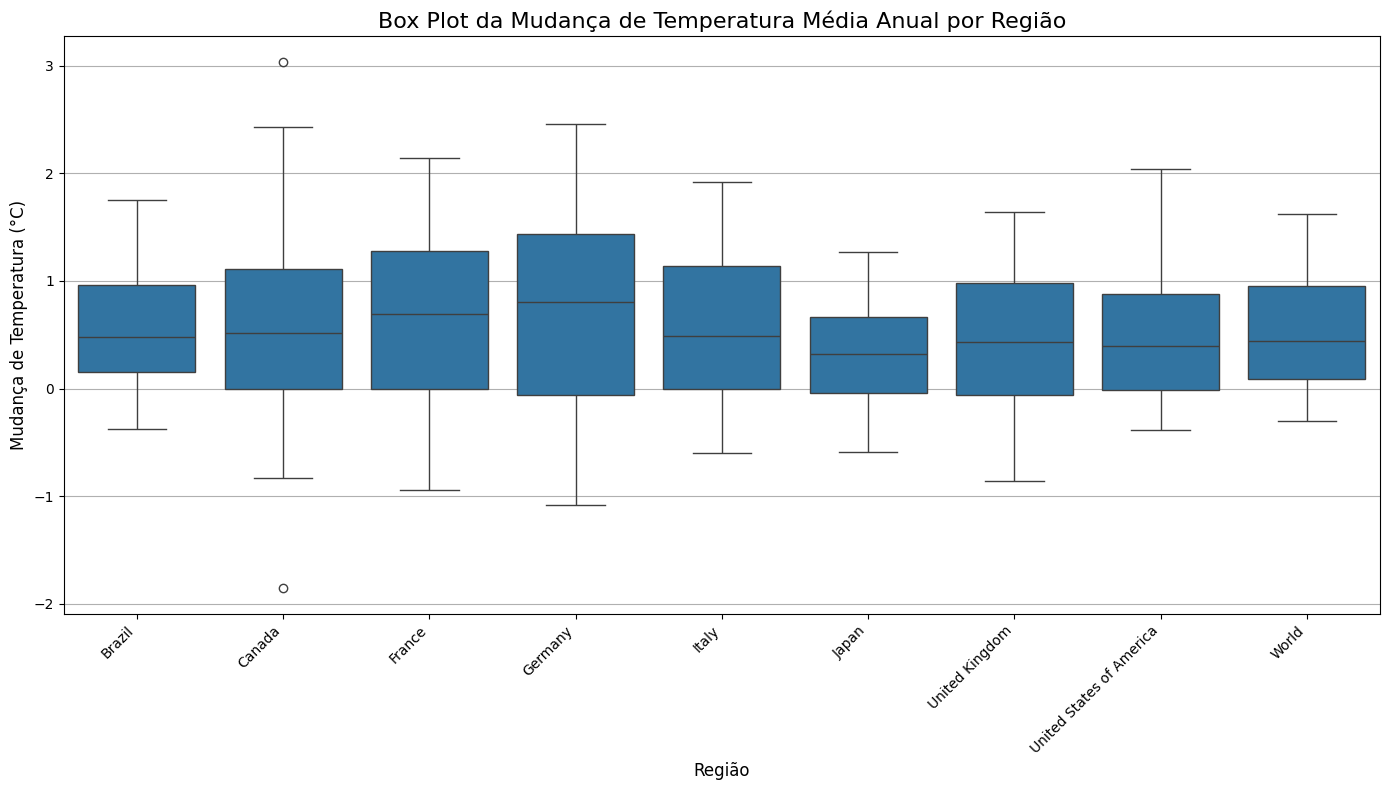


--- Verificando valores ausentes no dataset de temperatura final ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
dtype: int64

--- Percentual de valores ausentes ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
dtype: float64


In [102]:
# 2. Coleta e descrição dos dados

### 2.1 Temperatura

# --- 1. Carregamento e Visão Geral Inicial ---
# Carrega o dataset de mudança de temperatura da FAO.
# O encoding "ISO-8859-1" é especificado para evitar erros de leitura com caracteres especiais.
try:
    df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
    print("Dataset de temperatura carregado com sucesso!")
except FileNotFoundError:
    raise FileNotFoundError("Erro: O arquivo 'Environment_Temperature_change_E_All_Data_NOFLAG.csv' não foi encontrado. Certifique-se de que o caminho esteja correto.")

# --- Ajuste para o Formato do Dataset (Melting) ---
# O dataset original possui os anos como colunas (formato 'wide').
# Para facilitar a análise e o processamento, transformamos para o formato 'long' (melt).
# Isso cria uma coluna 'Year' e uma coluna 'Temperature_Change' com os valores correspondentes.
year_columns = [col for col in df.columns if col.startswith('Y') and len(col) == 5 and 'Y' not in col[1:]] # Garante que 'Y' esteja apenas no início, ex: Y1961
id_vars = [col for col in df.columns if col not in year_columns and 'F' not in col and 'Flag' not in col]

df_melted = df.melt(
    id_vars=id_vars,
    value_vars=year_columns,
    var_name='Year',
    value_name='Temperature_Change'
)

# Converte a coluna 'Year' para tipo inteiro, removendo o prefixo 'Y'.
df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
# Renomeia a coluna 'Area' para 'Country' para maior clareza e consistência.
df_melted.rename(columns={'Area': 'Country'}, inplace=True)

print("\n--- Dataset após 'melt' e renomeação de colunas ---")
display(df_melted.head()) # Usar display para melhor visualização no notebook
print(df_melted.info())

print("\n--- Valores únicos na coluna 'Element' ---")
# Mostra os diferentes tipos de dados de "Element" para entender o que está disponível.
print(df_melted['Element'].unique())

# --- 2. Filtragem de Dados de Interesse e do 'Element' ---
# Filtra o dataset para incluir apenas as linhas onde 'Element' é 'Temperature change',
# que é o foco principal deste projeto.
df_filtered_temp = df_melted[df_melted['Element'] == 'Temperature change'].copy()

# Define a lista de países do G7 e outras regiões de interesse (Brasil e Mundo).
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']

# Filtra o dataset para incluir apenas as regiões selecionadas.
df_filtered_temp = df_filtered_temp[df_filtered_temp['Country'].isin(selected_regions)].copy()

# Remove colunas que não são mais necessárias após a filtragem e agregação,
# para otimizar a memória e a clareza do DataFrame final.
columns_to_drop = [
    'Area Code', 'Months Code', 'Months', 'Element Code', 'Element', 'Unit'
]
df_filtered_temp.drop(columns=columns_to_drop, inplace=True, errors='ignore')


# --- AGREGAR POR ANO: Média anual da mudança de temperatura por país ---
# Agrupa os dados por 'Country' e 'Year' e calcula a média da 'Temperature_Change'.
# Isso garante que tenhamos uma única leitura de temperatura anual por país/região.
df_filtered_temp = (
    df_filtered_temp.groupby(['Country', 'Year'], as_index=False)
    .agg({'Temperature_Change': 'mean'})
)

print(f"\n--- Dataset de temperatura anual médio por região ({len(df_filtered_temp['Country'].unique())} regiões) ---")
display(df_filtered_temp.head())
print(df_filtered_temp.info())

# --- Estatísticas descritivas por país ---
# Exibe estatísticas descritivas (média, desvio padrão, min, max, quartis)
# para a 'Temperature_Change' por cada país/região.
# Isso fornece um resumo rápido da variação de temperatura em cada local.
print("\n--- Estatísticas descritivas da Mudança de Temperatura por País/Região ---")
display(df_filtered_temp.groupby('Country')['Temperature_Change'].describe())

# --- 3. Análise Exploratória Detalhada com Visualizações ---
print("\n--- Gerando visualizações para análise de tendências e distribuições ---")

# Aplicar média móvel de 3 anos para suavização das curvas de tendência.
# A média móvel ajuda a reduzir o ruído nos dados e a destacar tendências de longo prazo.
df_filtered_temp['Temp_SMA'] = df_filtered_temp.groupby('Country')['Temperature_Change'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Gráfico de tendência ao longo do tempo com suavização
# Visualiza a evolução da mudança de temperatura para cada região ao longo dos anos.
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_filtered_temp, x='Year', y='Temp_SMA', hue='Country', marker='o', errorbar=None)
plt.title('Mudança da Temperatura Média Anual ao Longo do Tempo por Região (com Média Móvel)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Mudança de Temperatura (°C)', fontsize=12)
plt.grid(True)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Histograma da distribuição das variações de temperatura
# Mostra a frequência com que diferentes valores de mudança de temperatura ocorrem no dataset.
# A curva KDE (Kernel Density Estimate) suaviza a distribuição para melhor visualização.
plt.figure(figsize=(12, 6))
sns.histplot(df_filtered_temp['Temperature_Change'], kde=True, bins=30, edgecolor='black')
plt.title('Distribuição da Mudança de Temperatura Média Anual', fontsize=16)
plt.xlabel('Mudança de Temperatura (°C)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True)
plt.show()

# Boxplot por região
# Compara a distribuição da mudança de temperatura entre as diferentes regiões.
# Permite identificar outliers e a dispersão dos dados para cada país/região.
plt.figure(figsize=(14, 8)) # Aumentei o tamanho para melhor visualização dos rótulos
sns.boxplot(x='Country', y='Temperature_Change', data=df_filtered_temp)
plt.title('Box Plot da Mudança de Temperatura Média Anual por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Mudança de Temperatura (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para evitar sobreposição
plt.grid(axis='y') # Apenas linhas de grade no eixo Y para melhor leitura
plt.tight_layout()
plt.show()

# --- Verificação de valores ausentes ---
# Confirma a ausência de valores nulos após todas as etapas de processamento.
print("\n--- Verificando valores ausentes no dataset de temperatura final ---")
print(df_filtered_temp.isnull().sum())
print("\n--- Percentual de valores ausentes ---")
print(df_filtered_temp.isnull().sum() / len(df_filtered_temp) * 100)

### 2.2 População


--- Dataset de População '../data/Population_E_All_Data_NOFLAG.csv' carregado com sucesso! ---

--- Primeiras 5 linhas do DataFrame de População recém-carregado ---


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1950,Y1951,...,Y2091,Y2092,Y2093,Y2094,Y2095,Y2096,Y2097,Y2098,Y2099,Y2100
0,2,'004,Afghanistan,3010,Population - Est. & Proj.,511,Total Population - Both sexes,1000 No,7776.176,7879.339,...,124110.001,124854.161,125589.411,126306.889,126990.147,127647.762,128305.496,128964.762,129616.118,130216.739
1,2,'004,Afghanistan,3010,Population - Est. & Proj.,512,Total Population - Male,1000 No,4118.834,4164.117,...,62209.223,62570.473,62927.649,63276.144,63607.509,63926.196,64245.639,64566.719,64884.666,65177.409
2,2,'004,Afghanistan,3010,Population - Est. & Proj.,513,Total Population - Female,1000 No,3657.341,3715.222,...,61900.779,62283.689,62661.762,63030.745,63382.637,63721.567,64059.858,64398.043,64731.452,65039.329
3,2,'004,Afghanistan,3010,Population - Est. & Proj.,551,Rural population,1000 No,7286.991,7352.856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,'004,Afghanistan,3010,Population - Est. & Proj.,561,Urban population,1000 No,465.127,486.654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Informações gerais do DataFrame de População ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Columns: 159 entries, Area Code to Y2100
dtypes: float64(151), int64(3), object(5)
memory usage: 1.7+ MB

--- Valores únicos da coluna 'Item' ---
['Population - Est. & Proj.']

--- Valores únicos da coluna 'Element' ---
['Total Population - Both sexes' 'Total Population - Male'
 'Total Population - Female' 'Rural population' 'Urban population']

--- Head do DataFrame de População após melt e renomeação ---


,Area Code,Country,Item Code,Item,Element Code,Element,Unit,Year,Population
0,2,Afghanistan,3010,Population - Est. & Proj.,511,Total Population - Both sexes,1000 No,1950,7776.176
1,2,Afghanistan,3010,Population - Est. & Proj.,512,Total Population - Male,1000 No,1950,4118.834
2,2,Afghanistan,3010,Population - Est. & Proj.,513,Total Population - Female,1000 No,1950,3657.341
3,2,Afghanistan,3010,Population - Est. & Proj.,551,Rural population,1000 No,1950,7286.991
4,2,Afghanistan,3010,Population - Est. & Proj.,561,Urban population,1000 No,1950,465.127



--- DataFrame de População Processado e Filtrado ---


,Country,Year,Population
145,Brazil,1950,53408551.0
190,Canada,1950,13741747.0
397,France,1950,41883119.0
427,Germany,1950,69847782.0
544,Italy,1950,46391673.0



--- Informações do DataFrame de População Processado ---
<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 145 to 208965
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     1359 non-null   object 
 1   Year        1359 non-null   int32  
 2   Population  1359 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 37.2+ KB

--- Valores ausentes no DataFrame de População Processado (antes do merge) ---
Country       0
Year          0
Population    0
dtype: int64

--- DataFrame Final (Temperatura + População) após merge e interpolação ---


,Country,Year,Temperature_Change,Temp_SMA,Population
0,Brazil,1961,0.154824,0.154824,74605448.0
1,Brazil,1962,-0.176706,-0.010941,76865323.0
2,Brazil,1963,0.157824,0.045314,79164235.0
3,Brazil,1964,-0.268824,-0.095902,81488595.0
4,Brazil,1965,-0.028059,-0.046353,83817583.0



--- Informações do DataFrame Final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
 3   Temp_SMA            531 non-null    float64
 4   Population          531 non-null    float64
dtypes: float64(3), int32(1), object(1)
memory usage: 18.8+ KB

--- Valores ausentes no DataFrame Final ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
dtype: int64

--- Percentual de valores ausentes no DataFrame Final ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
dtype: float64

--- Gerando visualização de tendências populacionais por região ---

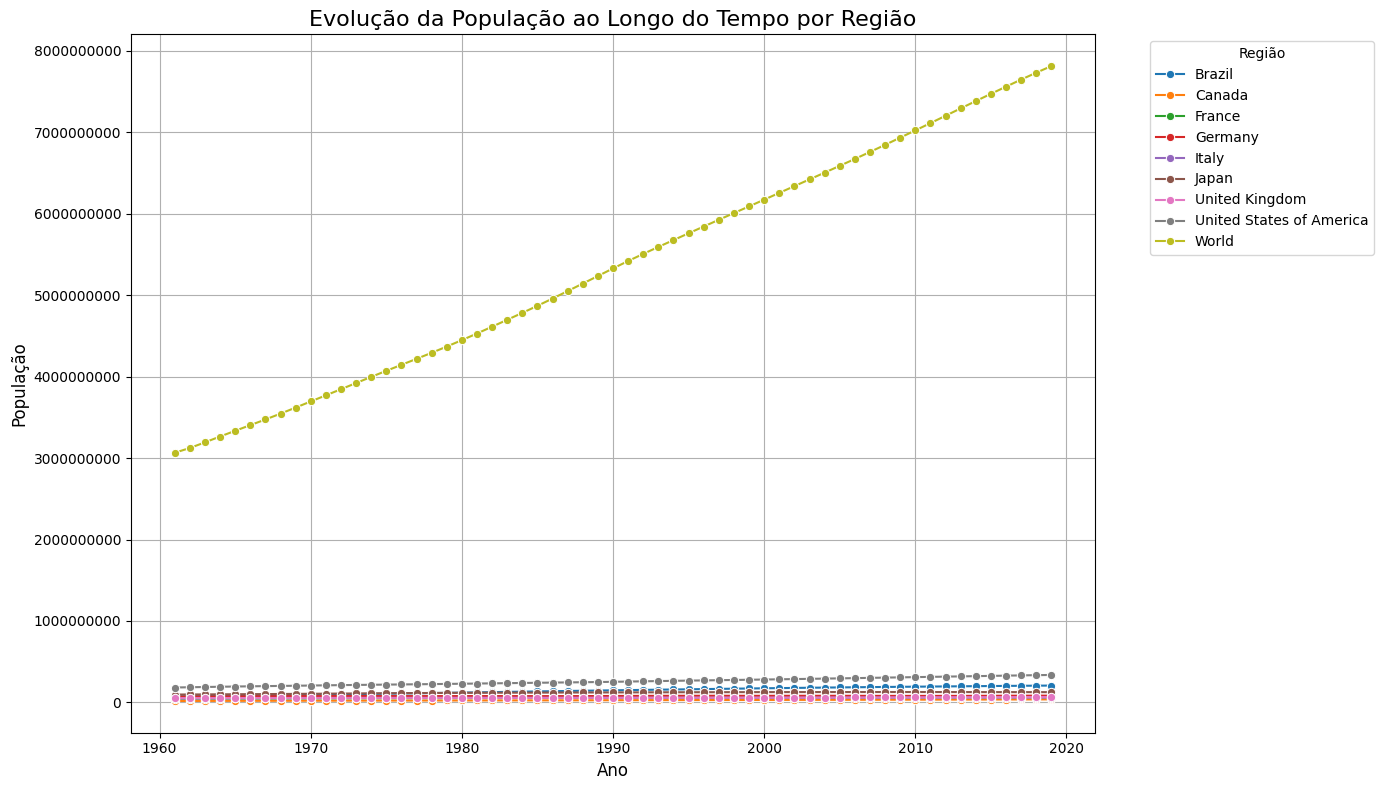

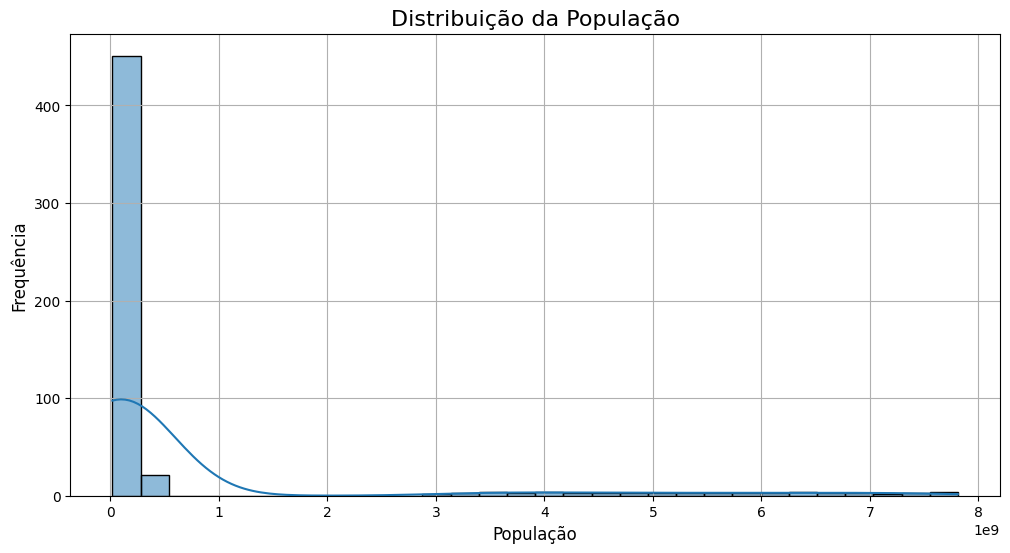

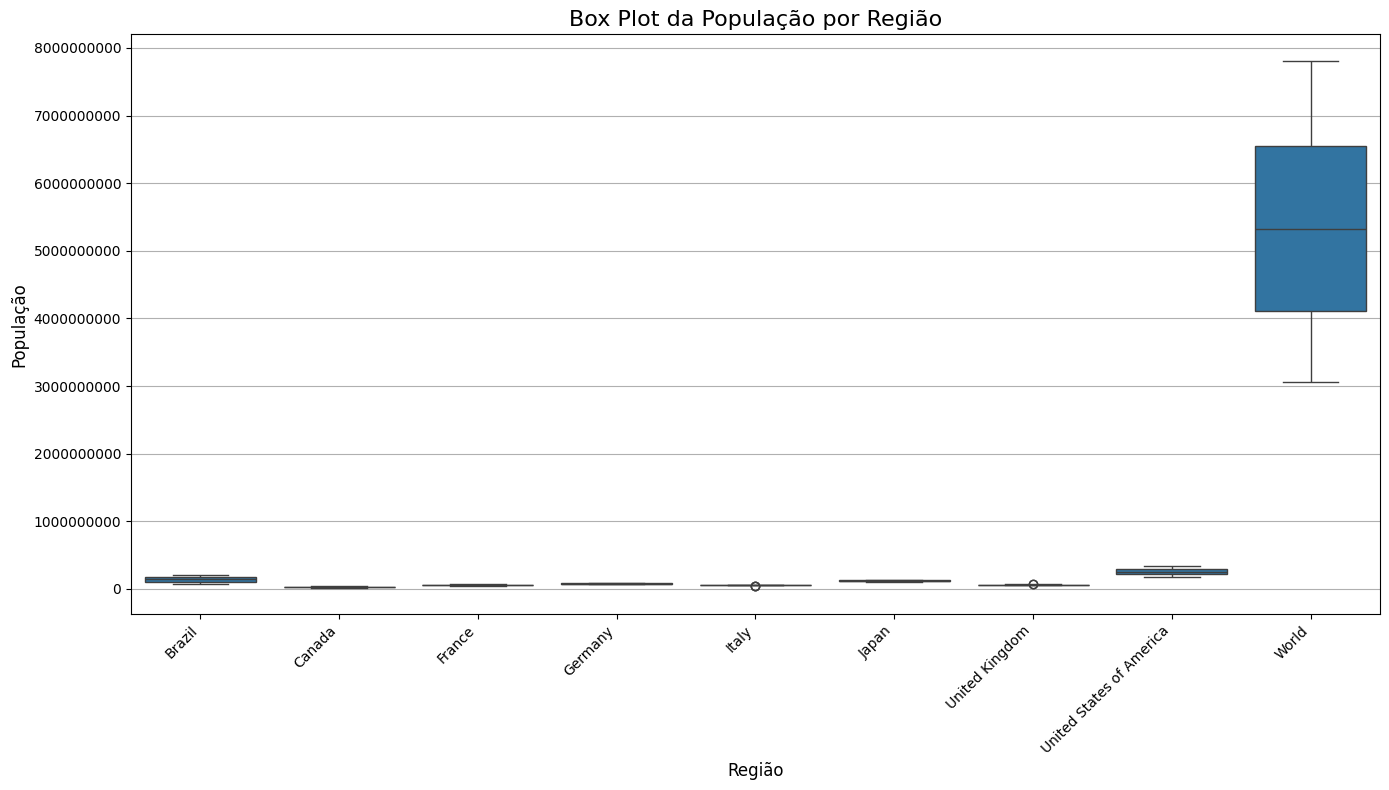

In [103]:
### 2.2 População: Carregamento, Pré-processamento e Merge

file_name_pop = "../data/Population_E_All_Data_NOFLAG.csv"

# --- 1. Carregamento do Dataset de População ---
try:
    df_pop = pd.read_csv(file_name_pop, encoding="ISO-8859-1")
    print(f"\n--- Dataset de População '{file_name_pop}' carregado com sucesso! ---")
except FileNotFoundError:
    # Se o arquivo não for encontrado, levanta um erro para interromper a execução e alertar o usuário.
    raise FileNotFoundError(f"Erro: O arquivo '{file_name_pop}' não foi encontrado. Verifique o caminho.")
except Exception as e:
    # Captura outras exceções que podem ocorrer durante o carregamento.
    raise Exception(f"Erro ao carregar o dataset de população: {e}")

print("\n--- Primeiras 5 linhas do DataFrame de População recém-carregado ---")
display(df_pop.head()) # Usar display para melhor visualização
print("\n--- Informações gerais do DataFrame de População ---")
df_pop.info()

# --- 2. Inspeção e Preparação para Transformação ---
# Verificação das colunas essenciais 'Item' e 'Element' para garantir a correta filtragem.
if 'Item' not in df_pop.columns or 'Element' not in df_pop.columns:
    raise ValueError("Colunas 'Item' ou 'Element' não encontradas no dataset de população. Verifique a estrutura do arquivo.")

print("\n--- Valores únicos da coluna 'Item' ---")
print(df_pop['Item'].unique())

print("\n--- Valores únicos da coluna 'Element' ---")
# Essencial para identificar o elemento de "População Total".
print(df_pop['Element'].unique())

# --- 3. Transformação do Dataset: Formato 'long' (melt) ---
# Identifica as colunas de identificação e as colunas que representam os anos.
# As colunas de ano começarão com 'Y' e terão 5 caracteres (e.g., 'Y1960').
id_vars_pop = [
    'Area Code', 'Area', 'Item Code', 'Item',
    'Element Code', 'Element', 'Unit'
]
year_columns_pop = [col for col in df_pop.columns if col.startswith('Y') and len(col) == 5]

# Transforma o dataset de formato 'wide' (anos como colunas) para 'long' (anos em uma única coluna 'Year').
df_melted_pop = df_pop.melt(id_vars=id_vars_pop,
                             value_vars=year_columns_pop,
                             var_name='Year',
                             value_name='Population')

# Converte a coluna 'Year' de string (e.g., 'Y1960') para inteiro.
df_melted_pop['Year'] = df_melted_pop['Year'].str.replace('Y', '').astype(int)
# Renomeia a coluna 'Area' para 'Country' para consistência com o dataset de temperatura.
df_melted_pop.rename(columns={'Area': 'Country'}, inplace=True)

# --- 4. Padronização do Nome do País ---
# Corrige o nome extenso do Reino Unido para corresponder ao dataset de temperatura.
df_melted_pop['Country'] = df_melted_pop['Country'].replace(
    'United Kingdom of Great Britain and Northern Ireland',
    'United Kingdom'
)
print("\n--- Head do DataFrame de População após melt e renomeação ---")
display(df_melted_pop.head())

# --- 5. Filtragem de Dados de Interesse ---
# Filtra o dataset para o elemento específico de "População Total - Ambos os sexos".
population_element = 'Total Population - Both sexes'
if population_element not in df_melted_pop['Element'].unique():
    raise ValueError(f"Elemento '{population_element}' não encontrado na coluna 'Element'. Verifique os valores únicos.")

df_filtered_pop = df_melted_pop[df_melted_pop['Element'] == population_element].copy()

# Filtra o dataset para incluir apenas as regiões de interesse (Brasil, G7 e Mundo).
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']
df_filtered_pop = df_filtered_pop[df_filtered_pop['Country'].isin(selected_regions)].copy()

# --- 6. Conversão de Unidade e Limpeza ---
# Converte a população de milhares (como vem no dataset da FAO) para unidades (número real de pessoas).
df_filtered_pop['Population'] = pd.to_numeric(df_filtered_pop['Population'], errors='coerce') * 1000

# Remove linhas onde 'Population' ou 'Year' são NaN, pois são essenciais para o merge e análise.
# Embora a interpolação seja feita depois, remover NaNs aqui antes de colunas desnecessárias pode otimizar.
df_filtered_pop.dropna(subset=['Population', 'Year'], inplace=True)

# Seleciona apenas as colunas relevantes para o merge e análise.
columns_to_keep_pop = ['Country', 'Year', 'Population']
df_filtered_pop = df_filtered_pop[columns_to_keep_pop].copy() # Usar .copy() para evitar SettingWithCopyWarning

print("\n--- DataFrame de População Processado e Filtrado ---")
display(df_filtered_pop.head())
print("\n--- Informações do DataFrame de População Processado ---")
df_filtered_pop.info()
print("\n--- Valores ausentes no DataFrame de População Processado (antes do merge) ---")
print(df_filtered_pop.isnull().sum())

# --- 7. Merge com o Dataset de Temperatura ---
# Realiza um merge do DataFrame de temperatura (df_filtered_temp) com o DataFrame de população.
# O merge é feito com base nas colunas 'Country' e 'Year'.
# 'how='left'' garante que todas as entradas de temperatura sejam mantidas, e a população correspondente seja adicionada.
# Linhas onde não há correspondência de população terão NaN na coluna 'Population'.
df_merged_temp_pop = pd.merge(df_filtered_temp, df_filtered_pop, on=['Country', 'Year'], how='left')

# --- 8. Tratamento de Valores Ausentes na População (pós-merge) ---
# Interpolação linear para preencher NaNs na coluna 'Population' para cada país.
# 'limit_direction='both'' tenta preencher NaNs no início, meio e fim da série.
# df_merged_temp_pop['Population'] = df_merged_temp_pop.groupby('Country')['Population'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Adicionando um fallback para NaNs que ainda possam existir nas extremidades da série após a interpolação linear.
# 'ffill()' preenche NaNs com o último valor válido.
# 'bfill()' preenche NaNs restantes (no início da série) com o próximo valor válido.
# Essa abordagem garante que, se houver dados em uma extremidade da série temporal, NaNs adjacentes sejam preenchidos.
df_merged_temp_pop['Population'] = df_merged_temp_pop.groupby('Country')['Population'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both').ffill().bfill()
)
# É importante que o ffill e bfill venham depois da interpolação, e que sejam feitos por grupo (Country).

# --- 9. Verificação Final Pós-Tratamento ---
print("\n--- DataFrame Final (Temperatura + População) após merge e interpolação ---")
display(df_merged_temp_pop.head())
print("\n--- Informações do DataFrame Final ---")
df_merged_temp_pop.info()
print("\n--- Valores ausentes no DataFrame Final ---")
print(df_merged_temp_pop.isnull().sum())
print("\n--- Percentual de valores ausentes no DataFrame Final ---")
print(df_merged_temp_pop.isnull().sum() / len(df_merged_temp_pop) * 100)


# --- 10. Visualização da População por Região (Opcional, mas recomendado para EDA) ---
print("\n--- Gerando visualização de tendências populacionais por região ---")
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_merged_temp_pop, x='Year', y='Population', hue='Country', marker='o', errorbar=None)
plt.title('Evolução da População ao Longo do Tempo por Região', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('População', fontsize=12)
plt.grid(True)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.tight_layout()
plt.show()

# Histograma da distribuição da População (útil para entender a faixa de valores)
plt.figure(figsize=(12, 6))
sns.histplot(df_merged_temp_pop['Population'], kde=True, bins=30, edgecolor='black')
plt.title('Distribuição da População', fontsize=16)
plt.xlabel('População', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True)
plt.show()

# Boxplot da População por Região
plt.figure(figsize=(14, 8))
sns.boxplot(x='Country', y='Population', data=df_merged_temp_pop)
plt.title('Box Plot da População por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('População', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.tight_layout()
plt.show()

### 2.3 Indicadores de Emissão de Gases


--- Dataset de Emissões '../data/Emissions_Totals_E_All_Data_NOFLAG.csv' carregado com sucesso! ---

--- Primeiras 5 linhas do DataFrame de Emissões recém-carregado ---


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Source Code,Source,Unit,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2030,Y2050
0,2,'004,Afghanistan,5064,Crop Residues,7234,Direct emissions (N2O),3050,FAO TIER 1,kt,...,1.2670,1.2154,1.0817,0.9194,1.2405,1.3433,1.0700,1.0254,1.5337,1.9389
1,2,'004,Afghanistan,5064,Crop Residues,7236,Indirect emissions (N2O),3050,FAO TIER 1,kt,...,0.2851,0.2735,0.2434,0.2069,0.2791,0.3022,0.2408,0.2307,0.3451,0.4362
2,2,'004,Afghanistan,5064,Crop Residues,7230,Emissions (N2O),3050,FAO TIER 1,kt,...,1.5521,1.4889,1.3251,1.1263,1.5197,1.6455,1.3108,1.2561,1.8788,2.3751
3,2,'004,Afghanistan,5064,Crop Residues,724313,Emissions (CO2eq) from N2O (AR5),3050,FAO TIER 1,kt,...,411.3065,394.5585,351.1515,298.4695,402.7205,436.0575,347.3620,332.8665,497.8820,629.4015
4,2,'004,Afghanistan,5064,Crop Residues,723113,Emissions (CO2eq) (AR5),3050,FAO TIER 1,kt,...,411.3065,394.5585,351.1515,298.4695,402.7205,436.0575,347.3620,332.8665,497.8820,629.4015



--- Informações gerais do DataFrame de Emissões ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65049 entries, 0 to 65048
Data columns (total 74 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area Code        65049 non-null  int64  
 1   Area Code (M49)  65049 non-null  object 
 2   Area             65049 non-null  object 
 3   Item Code        65049 non-null  int64  
 4   Item             65049 non-null  object 
 5   Element Code     65049 non-null  int64  
 6   Element          65049 non-null  object 
 7   Source Code      65049 non-null  int64  
 8   Source           65049 non-null  object 
 9   Unit             65049 non-null  object 
 10  Y1961            14459 non-null  float64
 11  Y1962            14459 non-null  float64
 12  Y1963            14459 non-null  float64
 13  Y1964            14459 non-null  float64
 14  Y1965            14459 non-null  float64
 15  Y1966            14471 non-null  float64
 16  Y1967

,Country,Year,CO2_Emissions
1893241,Brazil,1990,2.261191e+05
1895422,Canada,1990,4.536551e+05
1905050,France,1990,3.928239e+05
1906425,Germany,1990,1.047908e+06
1911899,Italy,1990,4.288420e+05



--- Informações do DataFrame de Emissões Processado ---
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1893241 to 4024435
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        297 non-null    object 
 1   Year           297 non-null    int32  
 2   CO2_Emissions  297 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 8.1+ KB

--- Valores ausentes no DataFrame de Emissões Processado (antes do merge) ---
Country          0
Year             0
CO2_Emissions    0
dtype: int64

--- DataFrame Final (Temperatura + População + Emissões) após merge e tratamento de NaNs ---


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions
0,Brazil,1961,0.154824,0.154824,74605448.0,226119.1332
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332
5,Brazil,1966,0.035882,-0.087000,86139359.0,226119.1332
6,Brazil,1967,0.057824,0.021882,88446124.0,226119.1332
7,Brazil,1968,-0.377529,-0.094608,90741240.0,226119.1332
8,Brazil,1969,0.353941,0.011412,93045777.0,226119.1332
9,Brazil,1970,0.152412,0.042941,95375651.0,226119.1332



--- Informações do DataFrame Final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
 3   Temp_SMA            531 non-null    float64
 4   Population          531 non-null    float64
 5   CO2_Emissions       531 non-null    float64
dtypes: float64(4), int32(1), object(1)
memory usage: 22.9+ KB

--- Valores ausentes no DataFrame Final ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
dtype: int64

--- Percentual de valores ausentes no DataFrame Final ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissi

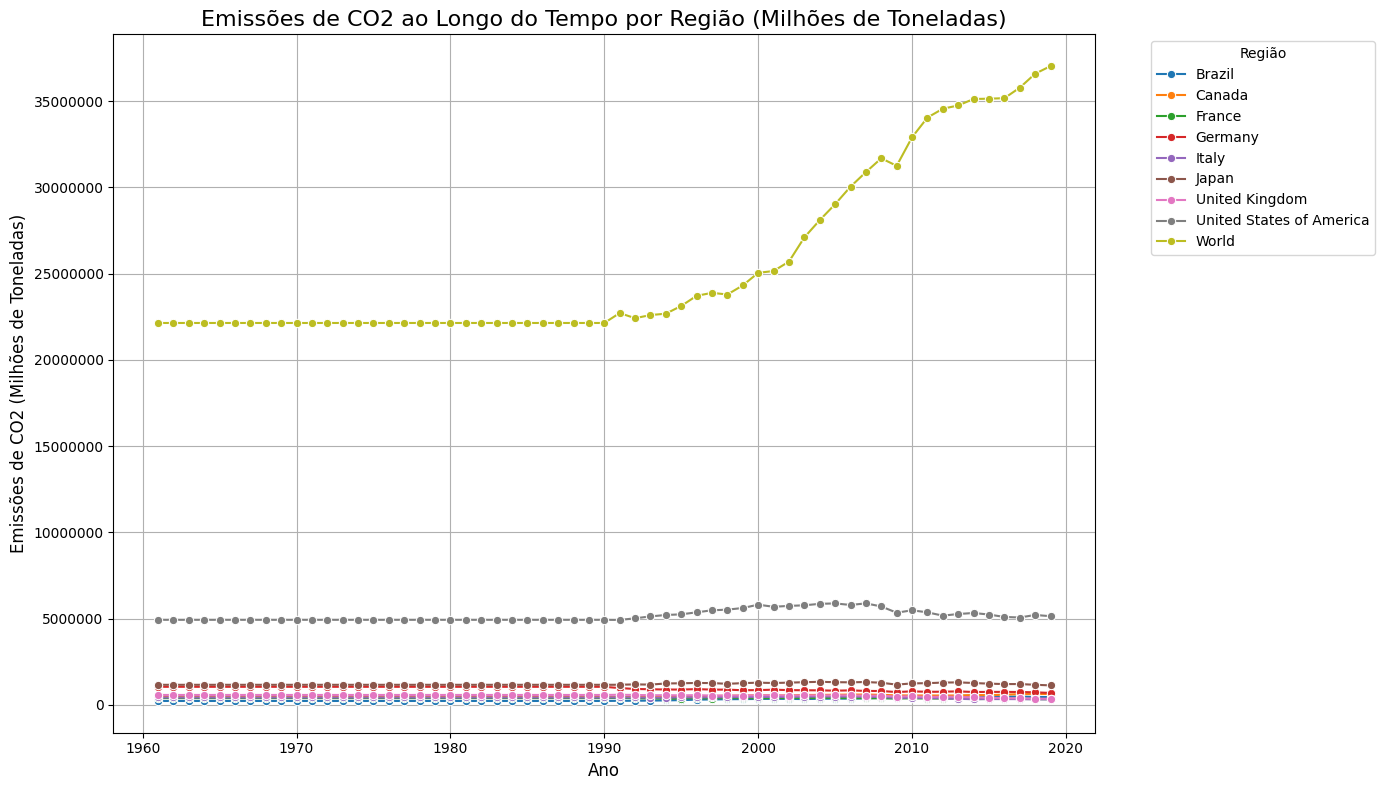

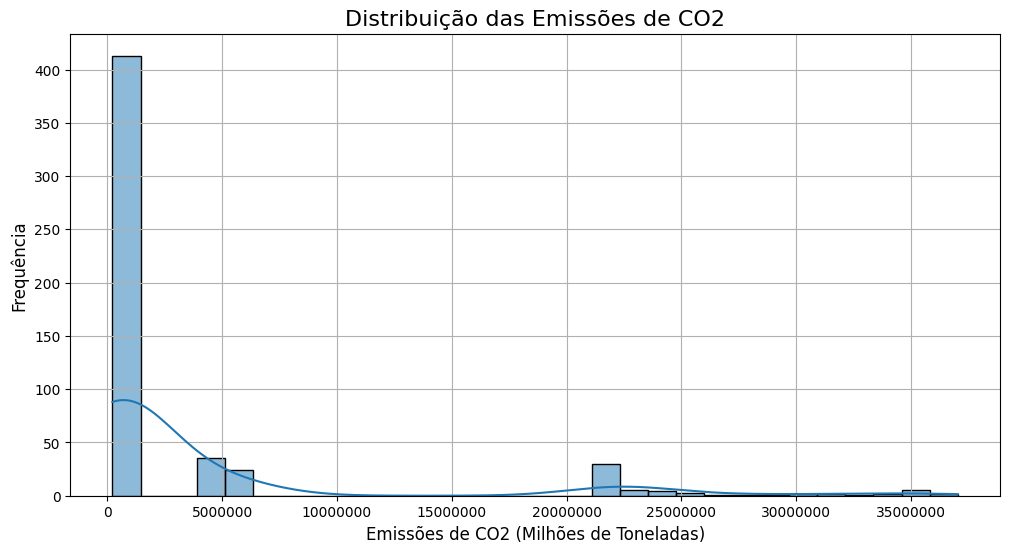

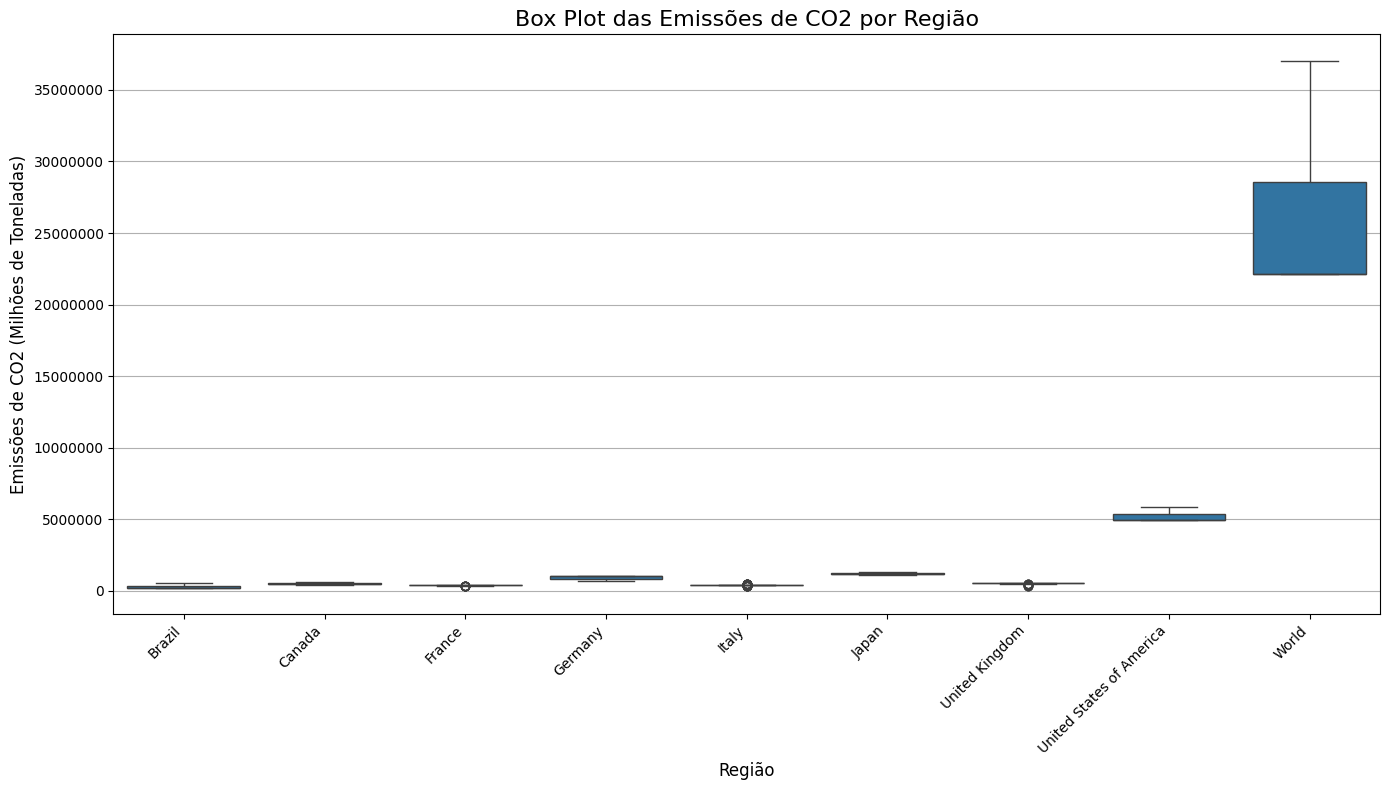

In [104]:
# Caminho para o arquivo de dados de emissões
file_name_emissions = "../data/Emissions_Totals_E_All_Data_NOFLAG.csv"

try:
    # --- 1. Carregamento do Dataset de Emissões ---
    df_emissions = pd.read_csv(file_name_emissions, encoding="ISO-8859-1")
    print(f"\n--- Dataset de Emissões '{file_name_emissions}' carregado com sucesso! ---")

    print("\n--- Primeiras 5 linhas do DataFrame de Emissões recém-carregado ---")
    display(df_emissions.head())
    print("\n--- Informações gerais do DataFrame de Emissões ---")
    df_emissions.info()
    print("\n--- Valores únicos na coluna 'Item' ---")
    print(df_emissions['Item'].unique())
    print("\n--- Valores únicos na coluna 'Element' ---")
    print(df_emissions['Element'].unique())

    # --- 2. Transformação do Dataset: Formato 'long' (melt) ---
    # Identifica as colunas de identificação e as colunas de anos para o melt.
    id_vars_emissions = [
        'Area Code', 'Area', 'Item Code', 'Item',
        'Element Code', 'Element', 'Unit'
    ]
    year_columns_emissions = [col for col in df_emissions.columns if col.startswith('Y') and len(col) == 5]

    df_melted_emissions = df_emissions.melt(
        id_vars=id_vars_emissions,
        value_vars=year_columns_emissions,
        var_name='Year',
        value_name='CO2_Emissions' # Renomeia a coluna de valores para CO2_Emissions
    )

    # Converte a coluna 'Year' para tipo inteiro e renomeia 'Area' para 'Country'.
    df_melted_emissions['Year'] = df_melted_emissions['Year'].str.replace('Y', '').astype(int)
    df_melted_emissions.rename(columns={'Area': 'Country'}, inplace=True)

    # --- 3. Padronização do Nome do País (se necessário, igual à população) ---
    # É crucial que os nomes dos países sejam consistentes entre os datasets para o merge.
    df_melted_emissions['Country'] = df_melted_emissions['Country'].replace(
        'United Kingdom of Great Britain and Northern Ireland',
        'United Kingdom'
    )

    # --- 4. Filtragem por Item e Elemento de Interesse ---
    # Seleciona o item e o elemento específicos para emissões de CO2.
    # 'All sectors without LULUCF' é uma medida comum para emissões totais de CO2,
    # excluindo mudanças no uso da terra que podem ter dinâmicas próprias.
    emissions_item = 'All sectors without LULUCF'
    element_type = 'Emissions (CO2)'

    # Valida se os valores esperados estão presentes no dataset.
    if emissions_item not in df_melted_emissions['Item'].unique():
        raise ValueError(f"Item '{emissions_item}' não encontrado na coluna 'Item' no dataset de emissões.")
    if element_type not in df_melted_emissions['Element'].unique():
        raise ValueError(f"Elemento '{element_type}' não encontrado na coluna 'Element' no dataset de emissões.")

    df_filtered_emissions = df_melted_emissions[
        (df_melted_emissions['Item'] == emissions_item) &
        (df_melted_emissions['Element'] == element_type)
    ].copy() # Usar .copy() para evitar SettingWithCopyWarning

    # --- 5. Filtragem por Países/Regiões de Interesse ---
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
    selected_regions = ['Brazil'] + g7_countries + ['World']

    df_filtered_emissions = df_filtered_emissions[df_filtered_emissions['Country'].isin(selected_regions)].copy()

    # Converte a coluna 'CO2_Emissions' para numérico, tratando não numéricos como NaN.
    df_filtered_emissions['CO2_Emissions'] = pd.to_numeric(df_filtered_emissions['CO2_Emissions'], errors='coerce')

    # Remove linhas onde 'CO2_Emissions' ou 'Year' são NaN antes do merge.
    # Isso garante que apenas dados válidos de emissões sejam mesclados.
    df_filtered_emissions.dropna(subset=['CO2_Emissions', 'Year'], inplace=True)

    # Seleciona apenas as colunas essenciais para o merge.
    df_filtered_emissions = df_filtered_emissions[['Country', 'Year', 'CO2_Emissions']].copy()

    print("\n--- Dataset de Emissões Processado e Filtrado (df_filtered_emissions) ---")
    display(df_filtered_emissions.head())
    print("\n--- Informações do DataFrame de Emissões Processado ---")
    df_filtered_emissions.info()
    print("\n--- Valores ausentes no DataFrame de Emissões Processado (antes do merge) ---")
    print(df_filtered_emissions.isnull().sum())

    # --- 6. Merge com o Dataset Combinado de Temperatura e População ---
    # Realiza um merge left para adicionar as emissões ao DataFrame existente (Temperatura + População).
    # Se não houver dados de emissão para um determinado País/Ano, a coluna 'CO2_Emissions' terá NaN.
    df_merged_temp_pop_emiss = pd.merge(
        df_merged_temp_pop, # DataFrame da etapa anterior
        df_filtered_emissions,
        on=['Country', 'Year'],
        how='left'
    )

    # --- 7. Tratamento de Valores Ausentes na Coluna 'CO2_Emissions' (pós-merge) ---
    # Dados de emissões podem não estar disponíveis para os primeiros anos (e.g., antes de 1990).
    # Optamos por preencher os NaNs com 0, assumindo que emissões muito antigas eram insignificantes
    # ou não são o foco principal do modelo se estiverem fora do período de dados mais relevantes.
    # Alternativamente, pode-se interpolar para lacunas e ffill/bfill para as extremidades.
    # No entanto, para dados que iniciam em um ponto específico, como emissões reguladas,
    # 0 pode ser mais apropriado do que uma interpolação de dados inexistentes.
    # df_merged_temp_pop_emiss['CO2_Emissions'].fillna(0, inplace=True) # Uma opção mais simples

    # Abordagem robusta: interpolar para lacunas e depois ffill/bfill para extremidades
    # Isso é bom se houver lacunas internas OU se os dados começarem em um ano intermediário.
    df_merged_temp_pop_emiss['CO2_Emissions'] = df_merged_temp_pop_emiss.groupby('Country')['CO2_Emissions'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both').ffill().bfill()
    )

    # Opcional: Se ainda existirem NaNs no início da série (antes do primeiro dado conhecido)
    # e você não quiser interpolar ou ffill com valores de outros países,
    # pode-se preencher esses NaNs remanescentes com 0 ou a média/mediana para a primeira década, etc.
    # Por agora, assumimos que a interpolação com ffill/bfill dará conta.

    print("\n--- DataFrame Final (Temperatura + População + Emissões) após merge e tratamento de NaNs ---")
    display(df_merged_temp_pop_emiss.head(10)) # Mostrando mais linhas para ver os NaNs iniciais preenchidos
    print("\n--- Informações do DataFrame Final ---")
    df_merged_temp_pop_emiss.info()
    print("\n--- Valores ausentes no DataFrame Final ---")
    print(df_merged_temp_pop_emiss.isnull().sum())
    print("\n--- Percentual de valores ausentes no DataFrame Final ---")
    print(df_merged_temp_pop_emiss.isnull().sum() / len(df_merged_temp_pop_emiss) * 100)

    # --- 8. Análise Exploratória Detalhada com Visualizações para Emissões ---
    print("\n--- Gerando visualizações para análise de tendências de Emissões ---")

    # Gráfico de tendência ao longo do tempo com suavização (se necessário, ou dados brutos)
    # Considerando a unidade de emissões (milhões de toneladas de CO2), é bom usar notação plain.
    plt.figure(figsize=(14, 8))
    sns.lineplot(data=df_merged_temp_pop_emiss, x='Year', y='CO2_Emissions', hue='Country', marker='o', errorbar=None)
    plt.title('Emissões de CO2 ao Longo do Tempo por Região (Milhões de Toneladas)', fontsize=16)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Emissões de CO2 (Milhões de Toneladas)', fontsize=12)
    plt.grid(True)
    plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
    plt.tight_layout()
    plt.show()

    # Histograma da distribuição das Emissões de CO2
    plt.figure(figsize=(12, 6))
    sns.histplot(df_merged_temp_pop_emiss['CO2_Emissions'], kde=True, bins=30, edgecolor='black')
    plt.title('Distribuição das Emissões de CO2', fontsize=16)
    plt.xlabel('Emissões de CO2 (Milhões de Toneladas)', fontsize=12)
    plt.ylabel('Frequência', fontsize=12)
    plt.grid(True)
    plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
    plt.show()

    # Boxplot das Emissões de CO2 por região
    plt.figure(figsize=(14, 8))
    sns.boxplot(x='Country', y='CO2_Emissions', data=df_merged_temp_pop_emiss)
    plt.title('Box Plot das Emissões de CO2 por Região', fontsize=16)
    plt.xlabel('Região', fontsize=12)
    plt.ylabel('Emissões de CO2 (Milhões de Toneladas)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y')
    plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro no processamento dos dados de emissões: {e}")


In [105]:
# Tratamento Final de Valores Ausentes (CO2_Emissions) 
# A coluna 'CO2_Emissions' pode conter NaNs, principalmente para os anos mais antigos,
# onde os dados de emissão podem não estar disponíveis ou não são relevantes para o período de análise.
# Optamos por remover as linhas que possuem valores NaN na coluna 'CO2_Emissions'.
# Esta abordagem garante que o modelo será treinado apenas em dados completos e consistentes,
# focando no período em que todos os indicadores estão disponíveis.
# Alternativamente, poderíamos ter interpolado ou preenchido esses valores (como discutido na seção anterior),
# mas a remoção é escolhida aqui para garantir a integridade total dos dados para o treinamento do modelo.
df_merged_temp_pop_emiss.dropna(subset=['CO2_Emissions'], inplace=True)

print("\n--- Valores ausentes após a remoção de NaNs em CO2_Emissions ---")
print(df_merged_temp_pop_emiss.isnull().sum())
print("\n--- Percentual de valores ausentes após a remoção de NaNs em CO2_Emissions ---")
print(df_merged_temp_pop_emiss.isnull().sum() / len(df_merged_temp_pop_emiss) * 100)
print("\n--- Primeiras 5 linhas do DataFrame final após remoção de NaNs ---")
display(df_merged_temp_pop_emiss.head()) # Usar display para melhor visualização
print("\n--- Informações do DataFrame final ---")
df_merged_temp_pop_emiss.info()


--- Valores ausentes após a remoção de NaNs em CO2_Emissions ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
dtype: int64

--- Percentual de valores ausentes após a remoção de NaNs em CO2_Emissions ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissions         0.0
dtype: float64

--- Primeiras 5 linhas do DataFrame final após remoção de NaNs ---


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions
0,Brazil,1961,0.154824,0.154824,74605448.0,226119.1332
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332



--- Informações do DataFrame final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
 3   Temp_SMA            531 non-null    float64
 4   Population          531 non-null    float64
 5   CO2_Emissions       531 non-null    float64
dtypes: float64(4), int32(1), object(1)
memory usage: 22.9+ KB


### 2.4 PIB per-capita


--- Dataset de PIB per capita '../data/pib_percapita.csv' carregado com sucesso! ---
Colunas disponíveis no DataFrame:


['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 'Unnamed: 69']


--- Dataset de PIB per capita processado (df_filtered_pib) ---
Registros encontrados: 576


,Country,Year,GDP_per_capita
29,Brazil,1960,235.266010
35,Canada,1960,2264.948497
55,Germany,1960,1162.122668
77,France,1960,1302.531497
81,United Kingdom,1960,1397.594803



Países encontrados nos dados de PIB:
['Brazil' 'Canada' 'Germany' 'France' 'United Kingdom' 'Italy' 'Japan'
 'United States of America' 'World']

Informações do DataFrame de PIB processado:
<class 'pandas.core.frame.DataFrame'>
Index: 576 entries, 29 to 17017
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         576 non-null    object 
 1   Year            576 non-null    int32  
 2   GDP_per_capita  576 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 15.8+ KB

Valores ausentes no DataFrame de PIB processado (antes do merge):
Country           0
Year              0
GDP_per_capita    0
dtype: int64

--- Merge com dados de PIB per capita concluído com sucesso. ---
Shape do dataframe final: (531, 7)

Amostra do dataframe final após merge:


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions,GDP_per_capita
0,Brazil,1961,0.154824,0.154824,74605448.0,226119.1332,231.564063
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332,250.200573
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332,294.169619
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332,257.259727
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332,268.028761



--- DataFrame Final (Temperatura + População + Emissões + PIB per capita) após tratamento de NaNs ---


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions,GDP_per_capita
0,Brazil,1961,0.154824,0.154824,74605448.0,226119.1332,231.564063
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332,250.200573
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332,294.169619
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332,257.259727
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332,268.028761
5,Brazil,1966,0.035882,-0.087000,86139359.0,226119.1332,328.343792
6,Brazil,1967,0.057824,0.021882,88446124.0,226119.1332,351.472600
7,Brazil,1968,-0.377529,-0.094608,90741240.0,226119.1332,373.925433
8,Brazil,1969,0.353941,0.011412,93045777.0,226119.1332,399.498419
9,Brazil,1970,0.152412,0.042941,95375651.0,226119.1332,443.799485



--- Informações do DataFrame Final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
 3   Temp_SMA            531 non-null    float64
 4   Population          531 non-null    float64
 5   CO2_Emissions       531 non-null    float64
 6   GDP_per_capita      531 non-null    float64
dtypes: float64(5), int32(1), object(1)
memory usage: 27.1+ KB

--- Valores ausentes por coluna no DataFrame Final ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
GDP_per_capita        0
dtype: int64

--- Percentual de valores ausentes por coluna no DataFrame Final ---
Country               0.0
Year               

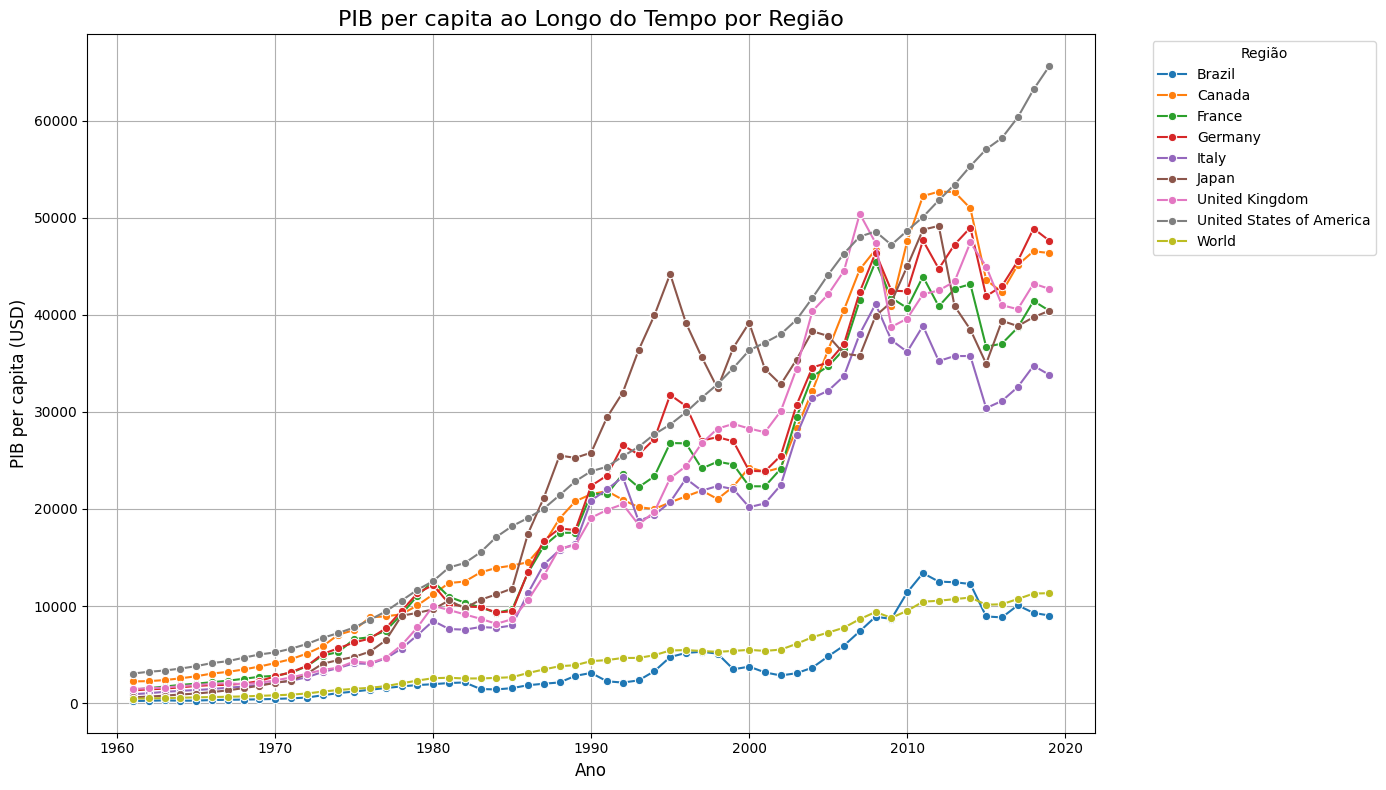

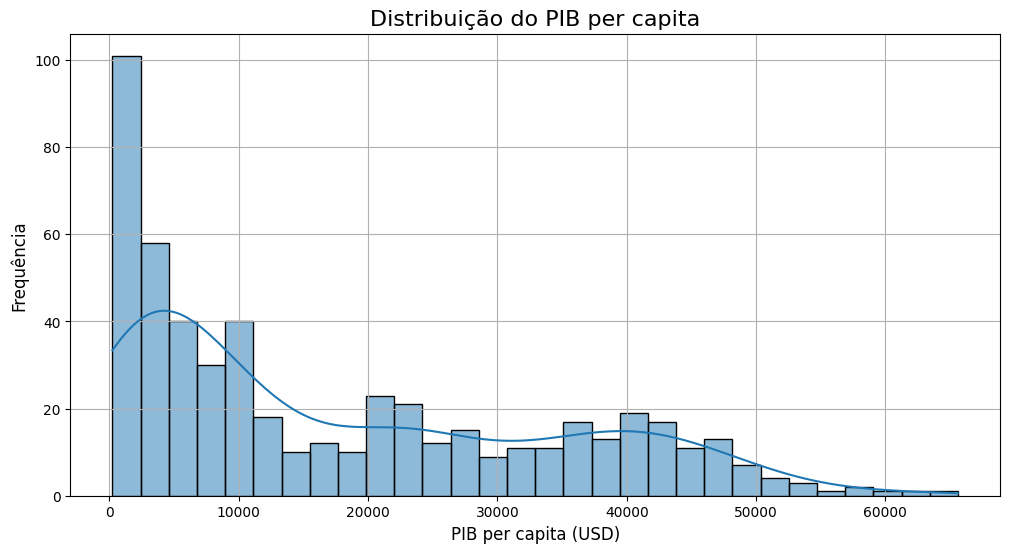

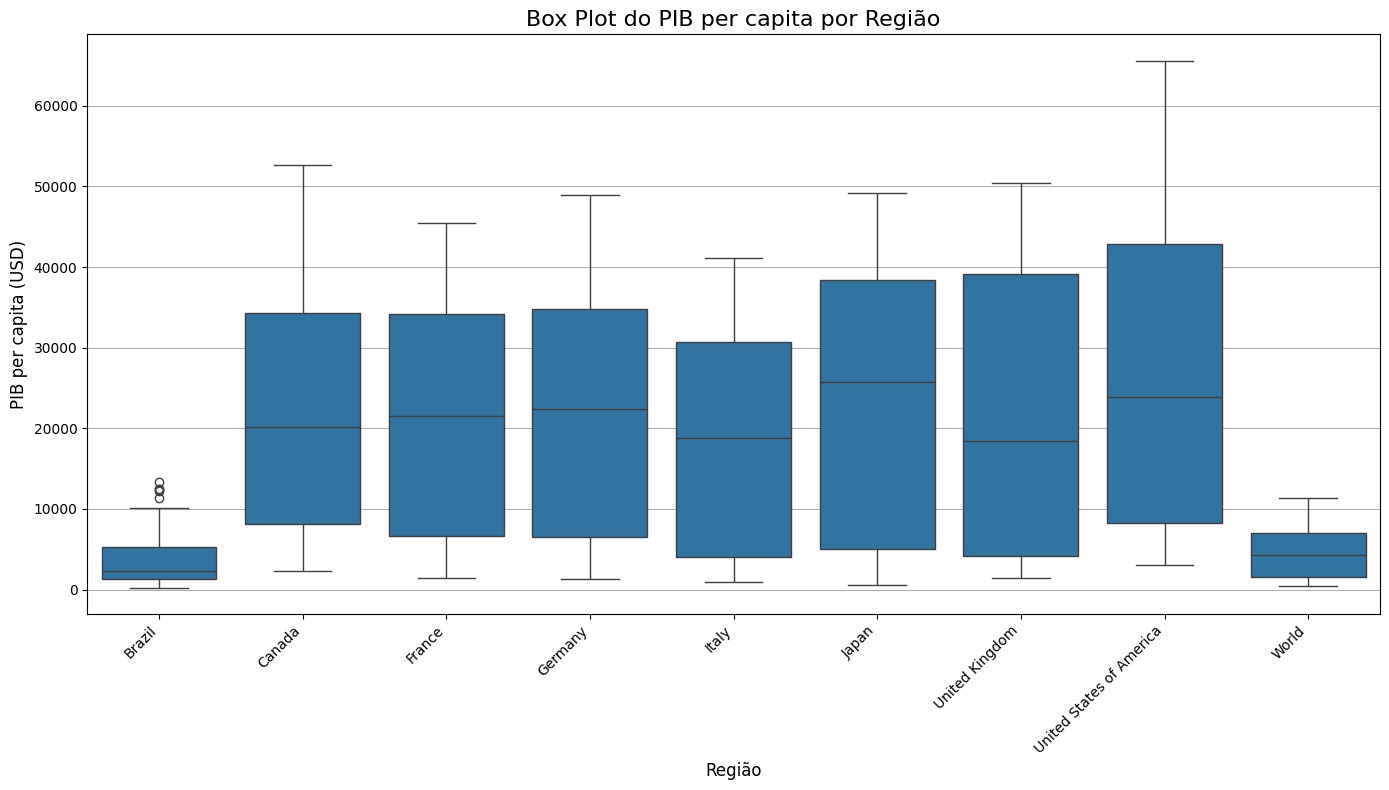

In [106]:
# Caminho para o arquivo de dados de PIB per capita
file_name_pib = "../data/pib_percapita.csv"

try:
    # --- 1. Carregamento do Dataset de PIB per capita ---
    # O arquivo do Banco Mundial geralmente tem metadados nas primeiras 4 linhas.
    # O encoding 'utf-8' é padrão e seguro para a maioria dos arquivos CSV.
    df_pib = pd.read_csv(file_name_pib, encoding="utf-8", skiprows=4)

    print(f"\n--- Dataset de PIB per capita '{file_name_pib}' carregado com sucesso! ---")
    print("Colunas disponíveis no DataFrame:")
    display(df_pib.columns.tolist()) # Usar display para melhor visualização

    # --- 2. Renomeação e Transformação do Dataset ---
    # Renomear a coluna de país para consistência com outros DataFrames.
    df_pib = df_pib.rename(columns={'Country Name': 'Country'})

    # Identificar colunas que representam anos (são strings de dígitos).
    year_cols = [col for col in df_pib.columns if col.isdigit()]
    
    # Selecionar apenas as colunas relevantes ('Country' e os anos).
    # Descartar 'Country Code', 'Indicator Name', 'Indicator Code' e 'Unnamed: 69' se não forem úteis.
    keep_cols = ['Country'] + year_cols
    df_pib = df_pib[keep_cols].copy() # Usar .copy() para evitar SettingWithCopyWarning

    # Derreter o dataframe para o formato 'long' (um ano por linha).
    df_melted_pib = df_pib.melt(
        id_vars=['Country'],
        value_vars=year_cols,
        var_name='Year',
        value_name='GDP_per_capita' # Nova coluna para os valores de PIB
    )

    # Converter a coluna 'Year' para tipo inteiro.
    df_melted_pib['Year'] = df_melted_pib['Year'].astype(int)

    # Converter a coluna 'GDP_per_capita' para numérico, tratando erros.
    df_melted_pib['GDP_per_capita'] = pd.to_numeric(df_melted_pib['GDP_per_capita'], errors='coerce')
    
    # --- 3. Padronização de Nomes de Países e Filtragem de Regiões ---
    # Países do G7 e outras regiões de interesse (Brasil e Mundo).
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
    # 'World' também pode estar presente neste dataset, mas verifique o nome exato.
    # Se 'World' for 'World', 'WLD', etc., precisará de um mapping.
    selected_regions = ['Brazil'] + g7_countries + ['World'] # Adicione 'World' se for um nome no dataset de PIB

    # Mapeamento para ajustar nomes de países para consistência com datasets anteriores.
    country_mapping = {
        'United States': 'United States of America',
        'Korea, Rep.': 'South Korea', # Exemplo, remova se não for usado
        'United Kingdom': 'United Kingdom' # Adicionado para clareza, pode não ser necessário se já for o nome correto
    }

    # Aplicar o mapeamento de nomes de países.
    df_melted_pib['Country'] = df_melted_pib['Country'].replace(country_mapping)
    
    # Filtrar o DataFrame para incluir apenas as regiões selecionadas.
    df_filtered_pib = df_melted_pib[df_melted_pib['Country'].isin(selected_regions)].copy()

    # Remover linhas onde 'GDP_per_capita' é NaN. Esta remoção é feita antes do merge
    # para evitar que linhas sem PIB válido entrem no dataset de PIB filtrado.
    df_filtered_pib.dropna(subset=['GDP_per_capita'], inplace=True)
    
    # --- 4. Verificação dos Dados de PIB Processados ---
    print("\n--- Dataset de PIB per capita processado (df_filtered_pib) ---")
    print(f"Registros encontrados: {len(df_filtered_pib)}")
    display(df_filtered_pib.head())
    print("\nPaíses encontrados nos dados de PIB:")
    print(df_filtered_pib['Country'].unique())
    print("\nInformações do DataFrame de PIB processado:")
    df_filtered_pib.info()
    print("\nValores ausentes no DataFrame de PIB processado (antes do merge):")
    print(df_filtered_pib.isnull().sum())
    
    # --- 5. Merge com o DataFrame Consolidado Anterior ---
    # O merge é feito com 'how=left' para manter todas as entradas de temperatura, população e emissões,
    # adicionando o PIB per capita correspondente.
    # Linhas sem correspondência de PIB terão NaN na coluna 'GDP_per_capita'.
    df_final = pd.merge(
        df_merged_temp_pop_emiss, # DataFrame das etapas anteriores
        df_filtered_pib,
        on=['Country', 'Year'],
        how='left'
    )
    
    print("\n--- Merge com dados de PIB per capita concluído com sucesso. ---")
    print(f"Shape do dataframe final: {df_final.shape}")
    print("\nAmostra do dataframe final após merge:")
    display(df_final.head())
    
    # --- 6. Tratamento de Valores Ausentes na Coluna 'GDP_per_capita' (pós-merge) ---
    # Preenchimento de NaNs na coluna 'GDP_per_capita' usando interpolação linear por país.
    # 'limit_direction='both'' tenta preencher NaNs no início, meio e fim da série.
    # 'ffill().bfill()' são usados como fallback para garantir que todas as lacunas
    # (especialmente nas extremidades da série temporal) sejam preenchidas com o valor mais próximo.
    df_final['GDP_per_capita'] = df_final.groupby('Country')['GDP_per_capita'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both').ffill().bfill()
    )

    # Após o tratamento de NaNs, verificar o estado final do DataFrame
    print("\n--- DataFrame Final (Temperatura + População + Emissões + PIB per capita) após tratamento de NaNs ---")
    display(df_final.head(10)) # Exibir mais linhas para verificar o preenchimento
    print("\n--- Informações do DataFrame Final ---")
    df_final.info()
    print("\n--- Valores ausentes por coluna no DataFrame Final ---")
    print(df_final.isnull().sum())
    print("\n--- Percentual de valores ausentes por coluna no DataFrame Final ---")
    print(df_final.isnull().sum() / len(df_final) * 100)

    # --- 7. Análise Exploratória Detalhada com Visualizações para PIB per capita ---
    print("\n--- Gerando visualizações para análise de tendências de PIB per capita ---")

    # Gráfico de tendência do PIB per capita ao longo do tempo por região
    plt.figure(figsize=(14, 8))
    sns.lineplot(data=df_final, x='Year', y='GDP_per_capita', hue='Country', marker='o', errorbar=None)
    plt.title('PIB per capita ao Longo do Tempo por Região', fontsize=16)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('PIB per capita (USD)', fontsize=12)
    plt.grid(True)
    plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
    plt.tight_layout()
    plt.show()

    # Histograma da distribuição do PIB per capita
    plt.figure(figsize=(12, 6))
    sns.histplot(df_final['GDP_per_capita'], kde=True, bins=30, edgecolor='black')
    plt.title('Distribuição do PIB per capita', fontsize=16)
    plt.xlabel('PIB per capita (USD)', fontsize=12)
    plt.ylabel('Frequência', fontsize=12)
    plt.grid(True)
    plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
    plt.show()

    # Boxplot do PIB per capita por região
    plt.figure(figsize=(14, 8))
    sns.boxplot(x='Country', y='GDP_per_capita', data=df_final)
    plt.title('Box Plot do PIB per capita por Região', fontsize=16)
    plt.xlabel('Região', fontsize=12)
    plt.ylabel('PIB per capita (USD)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y')
    plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nErro fatal ao processar dados de PIB per capita: {e}")
    # Diagnóstico adicional pode ser útil aqui, como você já tinha.
    # ... (manter o bloco de diagnóstico original se achar necessário)

In [107]:
# Tratamento Final de Valores Ausentes (PIB per capita) 
# Na etapa de merge, a coluna 'GDP_per_capita' pode ter introduzido valores NaN,
# especialmente para anos onde os dados de PIB não estavam disponíveis nos arquivos de origem.
# Para garantir um dataset completo para a modelagem, aplicamos uma estratégia de interpolação:
# 1. Interpolação linear por grupo de país: Preenche lacunas internas na série temporal de cada país.
#    'limit_direction='both'' é crucial para tentar preencher NaNs tanto no início quanto no final das séries.
# 2. Preenchimento forward-fill (ffill) e backward-fill (bfill): Após a interpolação linear,
#    ainda podem existir NaNs nas extremidades das séries temporais que a interpolação não alcança.
#    O ffill preenche os NaNs com o último valor válido anterior, e o bfill preenche os remanescentes
#    (geralmente no início da série) com o próximo valor válido.
# Essa combinação garante que todos os valores ausentes de PIB per capita sejam preenchidos de forma razoável,
# mantendo o número máximo de registros.

# Aplicar interpolação linear por grupo de país
df_final['GDP_per_capita'] = df_final.groupby('Country')['GDP_per_capita'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Preencher quaisquer NaNs remanescentes nas pontas com ffill (forward fill) e depois bfill (backward fill)
df_final['GDP_per_capita'] = df_final.groupby('Country')['GDP_per_capita'].transform(
    lambda x: x.ffill().bfill()
)

print("\n--- Valores ausentes após interpolação e preenchimento do PIB per capita ---")
print(df_final.isnull().sum())
print("\n--- Percentual de valores ausentes após interpolação e preenchimento do PIB per capita ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print("\n--- Amostra do DataFrame final após tratamento completo de NaNs no PIB ---")
display(df_final.head())
print("\n--- Informações do DataFrame final ---")
df_final.info()


--- Valores ausentes após interpolação e preenchimento do PIB per capita ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
GDP_per_capita        0
dtype: int64

--- Percentual de valores ausentes após interpolação e preenchimento do PIB per capita ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissions         0.0
GDP_per_capita        0.0
dtype: float64

--- Amostra do DataFrame final após tratamento completo de NaNs no PIB ---


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions,GDP_per_capita
0,Brazil,1961,0.154824,0.154824,74605448.0,226119.1332,231.564063
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332,250.200573
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332,294.169619
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332,257.259727
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332,268.028761



--- Informações do DataFrame final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             531 non-null    object 
 1   Year                531 non-null    int32  
 2   Temperature_Change  531 non-null    float64
 3   Temp_SMA            531 non-null    float64
 4   Population          531 non-null    float64
 5   CO2_Emissions       531 non-null    float64
 6   GDP_per_capita      531 non-null    float64
dtypes: float64(5), int32(1), object(1)
memory usage: 27.1+ KB


In [108]:
# Remover quaisquer NaNs remanescentes na coluna 'GDP_per_capita'
df_final.dropna(subset=['GDP_per_capita'], inplace=True)

print("\n--- VALIDAÇÃO FINAL: Valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum())
print("\n--- VALIDAÇÃO FINAL: Percentual de valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print(f"\n--- Shape final do DataFrame após todas as limpezas: {df_final.shape} ---")
print("\n--- Primeiras 5 linhas do DataFrame FINAL E LIMPO ---")
print(df_final.head())
print("\n--- Informações do DataFrame FINAL E LIMPO ---")
print(df_final.info())


--- VALIDAÇÃO FINAL: Valores ausentes em todo o DataFrame ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
GDP_per_capita        0
dtype: int64

--- VALIDAÇÃO FINAL: Percentual de valores ausentes em todo o DataFrame ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissions         0.0
GDP_per_capita        0.0
dtype: float64

--- Shape final do DataFrame após todas as limpezas: (531, 7) ---

--- Primeiras 5 linhas do DataFrame FINAL E LIMPO ---
  Country  Year  Temperature_Change  Temp_SMA  Population  CO2_Emissions  \
0  Brazil  1961            0.154824  0.154824  74605448.0    226119.1332   
1  Brazil  1962           -0.176706 -0.010941  76865323.0    226119.1332   
2  Brazil  1963            0.157824  0.045314  79164235.0    226119.1332   
3  Brazil  1964           -0.268824 -0.095902  81488595.

# 3. Engenharia de Features
Esta seção é dedicada à criação de novas features a partir dos dados existentes.
A engenharia de features é um passo crucial para melhorar o desempenho do modelo,
permitindo que ele capture relações mais complexas e padrões ocultos nos dados.
Serão criadas pelo menos 5 features derivadas, com foco em aspectos temporais,
taxas de mudança, e interações que possam influenciar a mudança de temperatura.

In [109]:
# Engenharia de Features Derivadas 

# Garantir ordenação para cálculo correto de diferenças e médias móveis
df_final = df_final.sort_values(by=['Country', 'Year'])

# Variação ano a ano de emissões e PIB per capita
df_final['CO2_Emissions_diff'] = df_final.groupby('Country')['CO2_Emissions'].diff()
df_final['GDP_per_capita_diff'] = df_final.groupby('Country')['GDP_per_capita'].diff()

# Média móvel de 5 anos da mudança de temperatura
df_final['Temperature_Change_rolling_mean'] = df_final.groupby('Country')['Temperature_Change']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Emissão per capita e sua média móvel
df_final['CO2_per_capita'] = df_final['CO2_Emissions'] / df_final['Population']
df_final['CO2_per_capita_rolling_mean'] = df_final.groupby('Country')['CO2_per_capita']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# PIB per capita comparado à média global no mesmo ano
gdp_global = df_final[df_final['Country'] == 'World'][['Year', 'GDP_per_capita']]\
    .rename(columns={'GDP_per_capita': 'GDP_global'})
df_final = pd.merge(df_final, gdp_global, on='Year', how='left')
df_final['GDP_vs_global'] = df_final['GDP_per_capita'] / df_final['GDP_global']


### 3.1 Análise Detalhada dos Dados Consolidados

In [110]:
print("\n--- Valores ausentes após Engenharia de Features ---")
print(df_final.isnull().sum())
print("\n--- Percentual de valores ausentes após Engenharia de Features ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print("\n--- Amostra do DataFrame com as novas features ---")
print(df_final.head())
print("\n--- Informações do DataFrame com as novas features ---")
print(df_final.info())


--- Valores ausentes após Engenharia de Features ---
Country                            0
Year                               0
Temperature_Change                 0
Temp_SMA                           0
Population                         0
CO2_Emissions                      0
GDP_per_capita                     0
CO2_Emissions_diff                 9
GDP_per_capita_diff                9
Temperature_Change_rolling_mean    0
CO2_per_capita                     0
CO2_per_capita_rolling_mean        0
GDP_global                         0
GDP_vs_global                      0
dtype: int64

--- Percentual de valores ausentes após Engenharia de Features ---
Country                            0.000000
Year                               0.000000
Temperature_Change                 0.000000
Temp_SMA                           0.000000
Population                         0.000000
CO2_Emissions                      0.000000
GDP_per_capita                     0.000000
CO2_Emissions_diff                 1.69

In [111]:
# Remover linhas com quaisquer NaNs remanescentes (de CO2_Emissions_diff e GDP_per_capita_diff)
df_final.dropna(inplace=True)

print("\n--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum())
print("\n--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Percentual de valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print(f"\n--- Shape final do DataFrame após TODAS as limpezas: {df_final.shape} ---")
print("\n--- Primeiras 5 linhas do DataFrame AGORA TOTALMENTE LIMPO E COM FEATURES ---")
print(df_final.head())
print("\n--- Informações do DataFrame AGORA TOTALMENTE LIMPO E COM FEATURES ---")
print(df_final.info())


--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Valores ausentes em todo o DataFrame ---
Country                            0
Year                               0
Temperature_Change                 0
Temp_SMA                           0
Population                         0
CO2_Emissions                      0
GDP_per_capita                     0
CO2_Emissions_diff                 0
GDP_per_capita_diff                0
Temperature_Change_rolling_mean    0
CO2_per_capita                     0
CO2_per_capita_rolling_mean        0
GDP_global                         0
GDP_vs_global                      0
dtype: int64

--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Percentual de valores ausentes em todo o DataFrame ---
Country                            0.0
Year                               0.0
Temperature_Change                 0.0
Temp_SMA                           0.0
Population                         0.0
CO2_Emissions                      0.0
GDP_per_capita                     0.0
CO2_Emissions_diff          

### 3.2 Validação Final do DataFrame Completo 


--- VALIDAÇÃO FINAL: Análise de Valores Ausentes ---


,Quantidade,Percentual
Country,0,0.0
Year,0,0.0
Temperature_Change,0,0.0
Temp_SMA,0,0.0
Population,0,0.0
CO2_Emissions,0,0.0
GDP_per_capita,0,0.0
CO2_Emissions_diff,0,0.0
GDP_per_capita_diff,0,0.0
Temperature_Change_rolling_mean,0,0.0


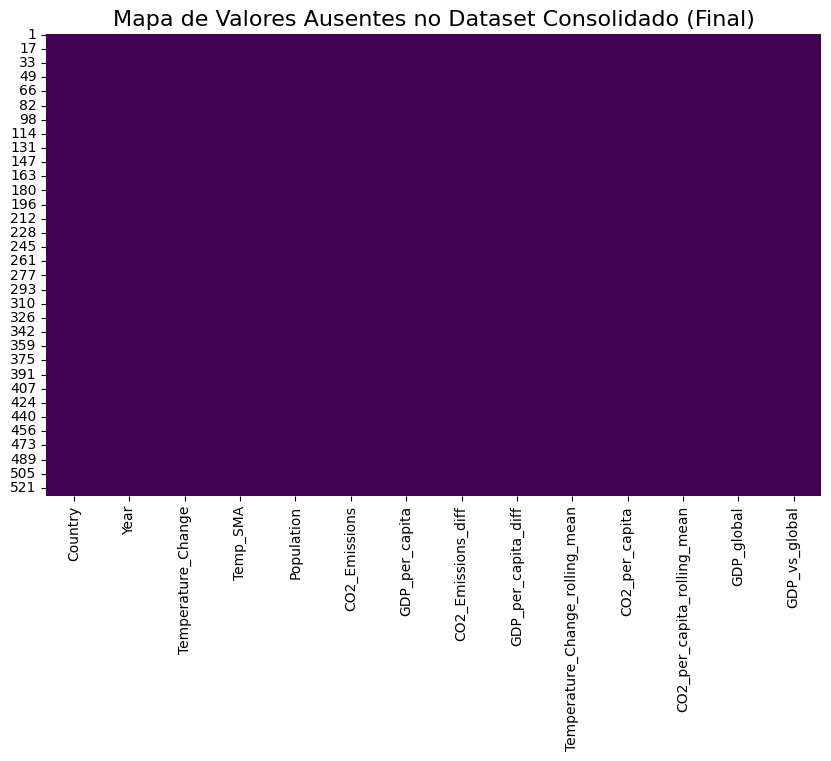


--- Shape final do DataFrame após todas as limpezas e engenharia de features: (522, 14) ---

--- Primeiras 5 linhas do DataFrame FINAL E LIMPO (com todas as features) ---


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions,GDP_per_capita,CO2_Emissions_diff,GDP_per_capita_diff,Temperature_Change_rolling_mean,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_global,GDP_vs_global
1,Brazil,1962,-0.176706,-0.010941,76865323.0,226119.1332,250.200573,0.0,18.636510,-0.010941,0.002942,0.002986,497.405226,0.503012
2,Brazil,1963,0.157824,0.045314,79164235.0,226119.1332,294.169619,0.0,43.969046,0.045314,0.002856,0.002943,524.351971,0.561016
3,Brazil,1964,-0.268824,-0.095902,81488595.0,226119.1332,257.259727,0.0,-36.909892,-0.033221,0.002775,0.002901,562.911681,0.457016
4,Brazil,1965,-0.028059,-0.046353,83817583.0,226119.1332,268.028761,0.0,10.769034,-0.032188,0.002698,0.002860,600.873476,0.446065
5,Brazil,1966,0.035882,-0.087000,86139359.0,226119.1332,328.343792,0.0,60.315031,-0.055976,0.002625,0.002779,637.857366,0.514761



--- Informações do DataFrame FINAL E LIMPO (com todas as features) ---
<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 530
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          522 non-null    object 
 1   Year                             522 non-null    int32  
 2   Temperature_Change               522 non-null    float64
 3   Temp_SMA                         522 non-null    float64
 4   Population                       522 non-null    float64
 5   CO2_Emissions                    522 non-null    float64
 6   GDP_per_capita                   522 non-null    float64
 7   CO2_Emissions_diff               522 non-null    float64
 8   GDP_per_capita_diff              522 non-null    float64
 9   Temperature_Change_rolling_mean  522 non-null    float64
 10  CO2_per_capita                   522 non-null    float64
 11  CO2_per_capita_ro

In [112]:
# Análise detalhada de valores ausentes em todo o DataFrame.
# Calcula a quantidade e o percentual de valores ausentes para cada coluna.
print("\n--- VALIDAÇÃO FINAL: Análise de Valores Ausentes ---")
missing_data = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100
missing_analysis = pd.concat([missing_data, missing_percent], axis=1)
missing_analysis.columns = ['Quantidade', 'Percentual']
display(missing_analysis) # Usar display para melhor visualização

# Visualização dos valores ausentes usando um mapa de calor.
# Um mapa completamente uniforme (sem marcas de cor para NaNs) confirmará a ausência de dados faltantes.
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis') # 'viridis' ou 'cividis' são bons para ausência/presença
plt.title('Mapa de Valores Ausentes no Dataset Consolidado (Final)', fontsize=16)
plt.show()

print(f"\n--- Shape final do DataFrame após todas as limpezas e engenharia de features: {df_final.shape} ---")
print("\n--- Primeiras 5 linhas do DataFrame FINAL E LIMPO (com todas as features) ---")
display(df_final.head()) # Usar display para melhor visualização
print("\n--- Informações do DataFrame FINAL E LIMPO (com todas as features) ---")
df_final.info()


--- Estatísticas Descritivas ---
       Country         Year  Temperature_Change    Temp_SMA    Population  \
count      522   522.000000          522.000000  522.000000  5.220000e+02   
unique       9          NaN                 NaN         NaN           NaN   
top     Brazil          NaN                 NaN         NaN           NaN   
freq        58          NaN                 NaN         NaN           NaN   
mean       NaN  1990.500000            0.536017    0.515237  6.880966e+08   
std        NaN    16.756727            0.688116    0.580074  1.728303e+09   
min        NaN  1962.000000           -1.849941   -0.705725  1.861360e+07   
25%        NaN  1976.000000            0.002662    0.021211  5.672736e+07   
50%        NaN  1990.500000            0.466382    0.449892  7.908565e+07   
75%        NaN  2005.000000            1.029235    0.970868  1.841849e+08   
max        NaN  2019.000000            3.033412    2.152510  7.811293e+09   

        CO2_Emissions  GDP_per_capita  CO

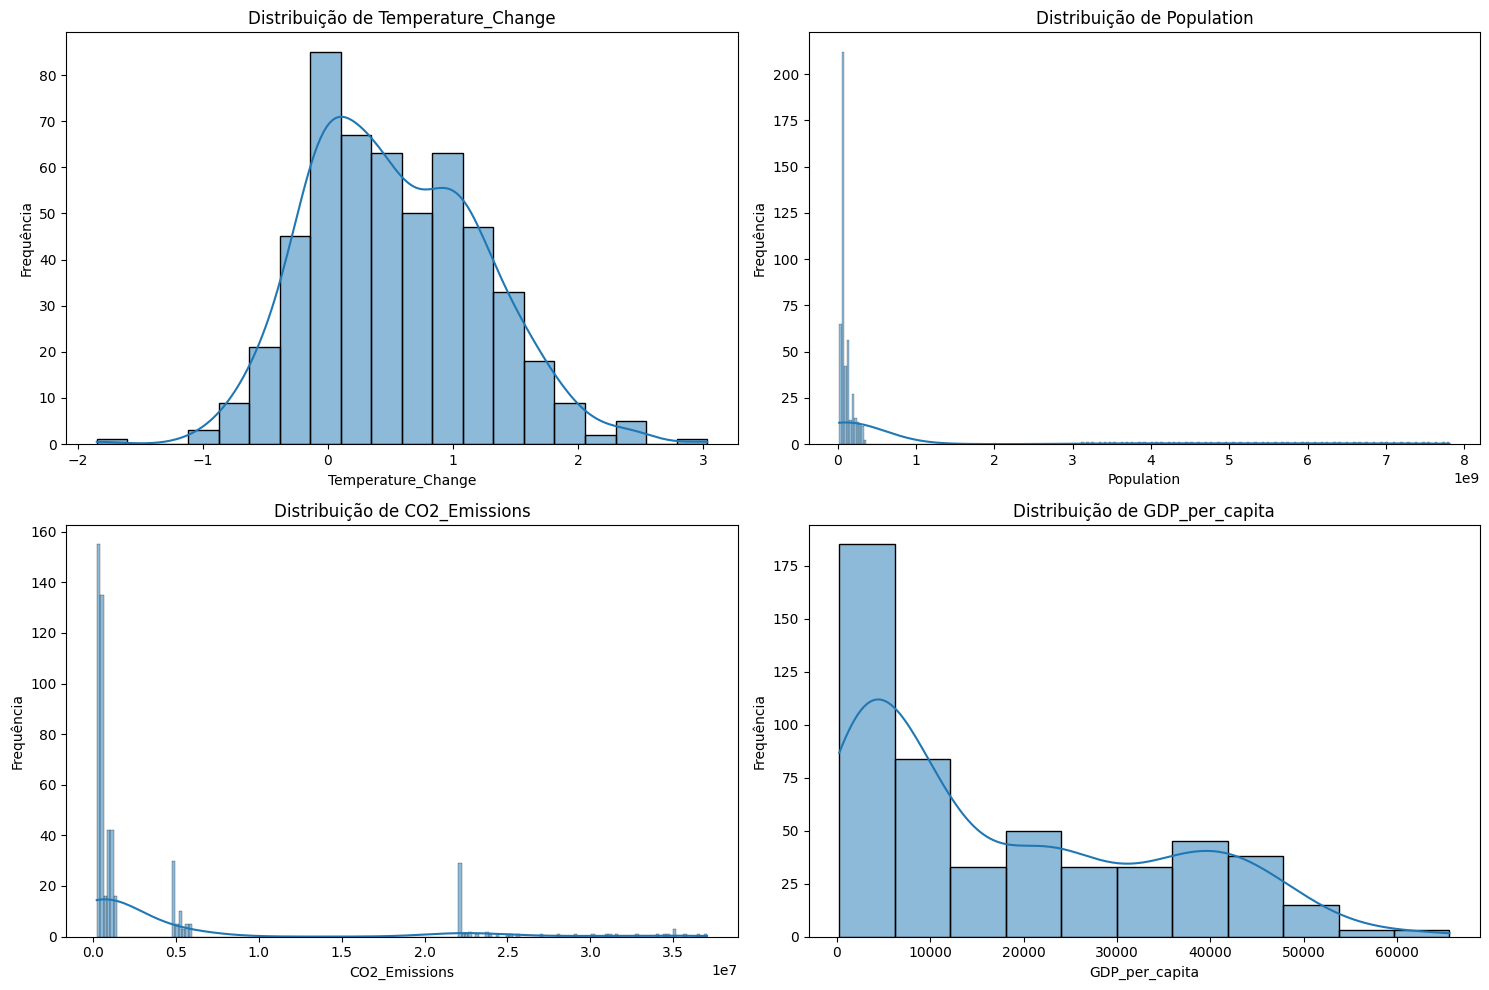

In [113]:
# Estatísticas descritivas
print("\n--- Estatísticas Descritivas ---")
print(df_final.describe(include='all'))

# Distribuição das variáveis numéricas
num_cols = ['Temperature_Change', 'Population', 'CO2_Emissions', 'GDP_per_capita']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_final[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### 3.4 Análise Temporal Combinada de Temperatura e Emissões de CO2 por Região
Esta subseção explora a evolução da Mudança de Temperatura Média e das Emissões de CO2
para cada país/região de interesse ao longo do tempo. O objetivo é visualizar as tendências
individuais e a relação aparente entre estas duas variáveis cruciais para o clima.

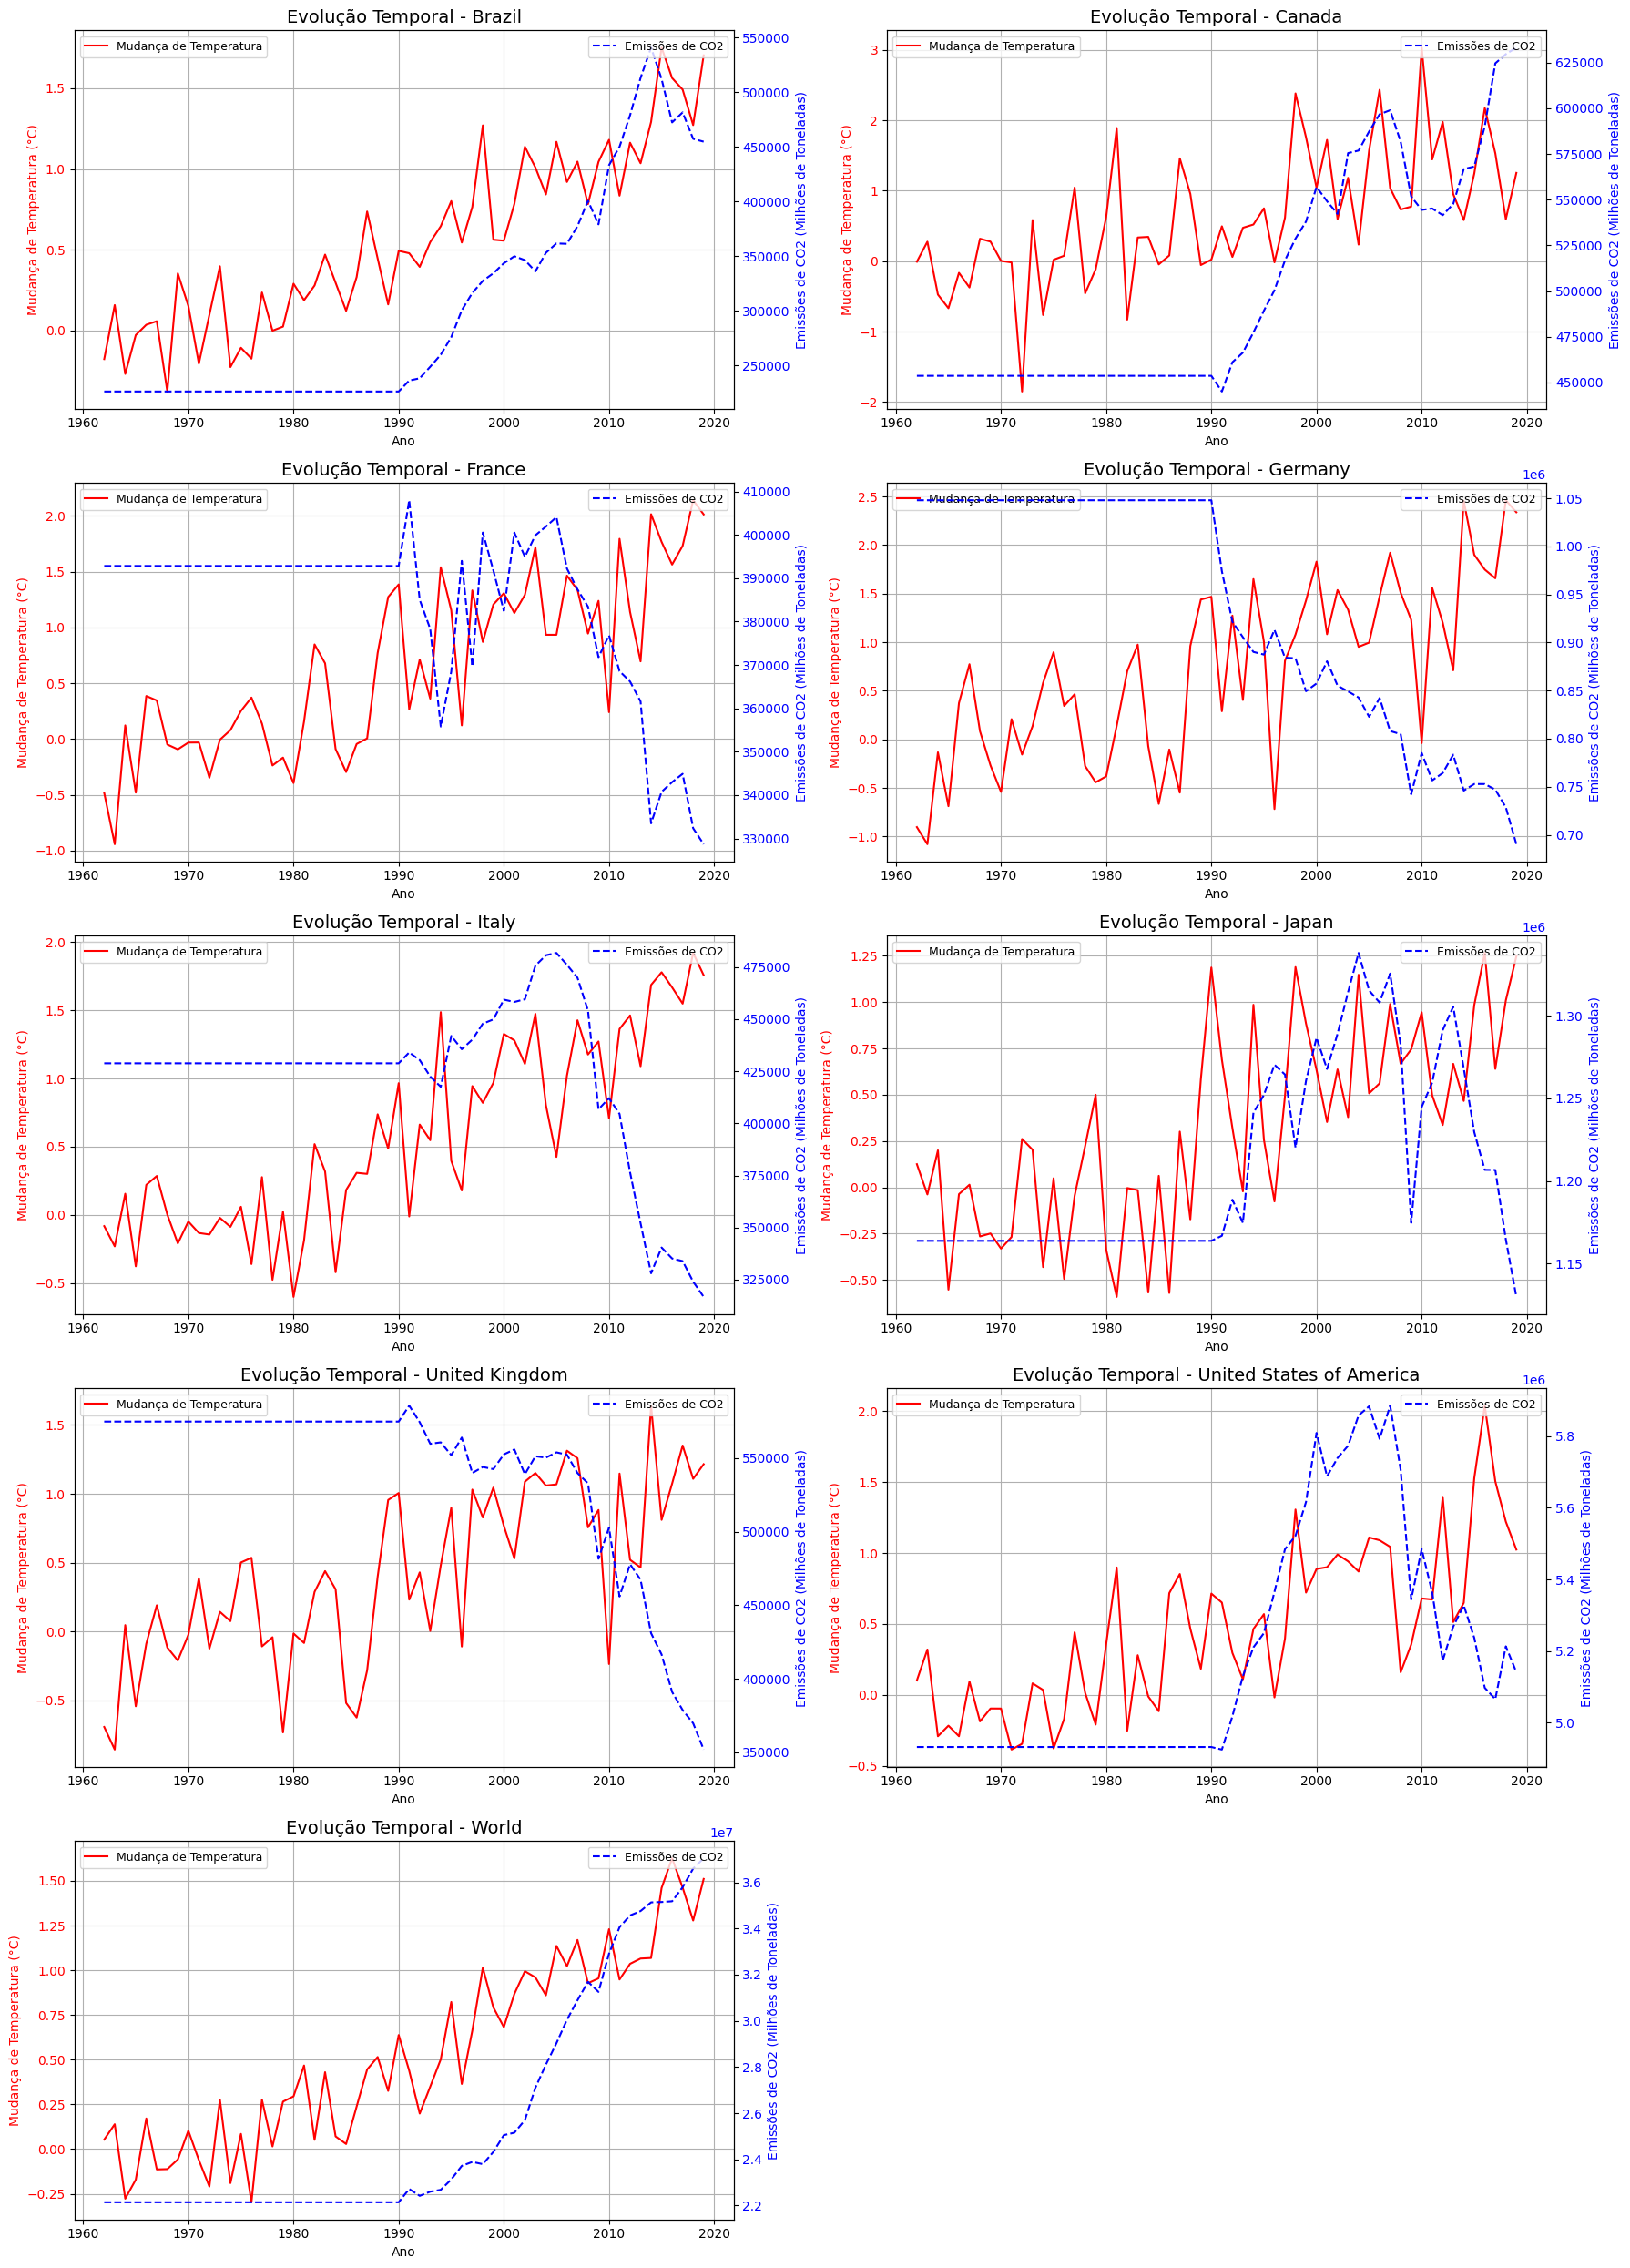

"\nAnálise e Interpretação dos Gráficos de Evolução Temporal:\n\nOs gráficos acima ilustram a evolução da Mudança de Temperatura Média Anual (linha vermelha)\ne das Emissões de CO2 (linha azul) para cada uma das regiões de interesse.\n\nObservações Principais:\n- Tendência de Aquecimento Global: Para a grande maioria das regiões e, de forma mais pronunciada, para a média mundial,\n  a linha da Mudança de Temperatura (`Temperature_Change`) demonstra uma clara tendência de aquecimento ao longo do tempo,\n  com flutuações anuais esperadas. Isso corrobora o fenômeno do aquecimento global.\n\n- Relação com Emissões de CO2:\n  - Crescimento Pós-1990: As Emissões de CO2 (`CO2_Emissions`) mostram um aumento significativo\n    para a maioria das regiões a partir de 1990 (ano de início dos dados completos de emissões após a limpeza).\n    A curva para 'World' é particularmente ilustrativa do crescimento global das emissões.\n  - Variações Regionais nas Emissões: Enquanto a temperatura geralmente

In [114]:

countries = df_final['Country'].unique()
n_countries = len(countries)
# Calcula o número necessário de linhas para organizar os subplots em 2 colunas
n_rows = (n_countries + 1) // 2

plt.figure(figsize=(18, 5 * n_rows))  # Ajusta a altura da figura dinamicamente
for i, country in enumerate(countries, 1):
    country_data = df_final[df_final['Country'] == country].sort_values(by='Year') # Garantir ordenação
    
    plt.subplot(n_rows, 2, i)  # Layout dinâmico: n_rows linhas, 2 colunas, i-ésimo subplot
    
    # Plot da Mudança de Temperatura (eixo Y esquerdo)
    plt.plot(country_data['Year'], country_data['Temperature_Change'], label='Mudança de Temperatura', color='red', linewidth=1.5)
    plt.title(f'Evolução Temporal - {country}', fontsize=14)
    plt.xlabel('Ano', fontsize=10)
    plt.ylabel('Mudança de Temperatura (°C)', fontsize=10, color='red')
    plt.tick_params(axis='y', labelcolor='red')
    plt.legend(loc='upper left', fontsize=9)
    plt.grid(True)
    
    # Cria um segundo eixo Y para as Emissões de CO2 (eixo Y direito)
    ax2 = plt.twinx()
    ax2.plot(country_data['Year'], country_data['CO2_Emissions'], label='Emissões de CO2', color='blue', linewidth=1.5, linestyle='--')
    ax2.set_ylabel('Emissões de CO2 (Milhões de Toneladas)', fontsize=10, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.legend(loc='upper right', fontsize=9)
    
plt.tight_layout() # Ajusta automaticamente os parâmetros do subplot para que caibam na área da figura
plt.show()

"""
Análise e Interpretação dos Gráficos de Evolução Temporal:

Os gráficos acima ilustram a evolução da Mudança de Temperatura Média Anual (linha vermelha)
e das Emissões de CO2 (linha azul) para cada uma das regiões de interesse.

Observações Principais:
- Tendência de Aquecimento Global: Para a grande maioria das regiões e, de forma mais pronunciada, para a média mundial,
  a linha da Mudança de Temperatura (`Temperature_Change`) demonstra uma clara tendência de aquecimento ao longo do tempo,
  com flutuações anuais esperadas. Isso corrobora o fenômeno do aquecimento global.

- Relação com Emissões de CO2:
  - Crescimento Pós-1990: As Emissões de CO2 (`CO2_Emissions`) mostram um aumento significativo
    para a maioria das regiões a partir de 1990 (ano de início dos dados completos de emissões após a limpeza).
    A curva para 'World' é particularmente ilustrativa do crescimento global das emissões.
  - Variações Regionais nas Emissões: Enquanto a temperatura geralmente segue uma tendência de alta,
    as emissões de CO2 em alguns países do G7 (como Alemanha e Reino Unido) mostram picos seguidos de platô
    ou até declínio em anos mais recentes. Isso pode refletir esforços de descarbonização,
    mudanças na estrutura econômica ou realocação industrial.
  - Inércia Climática: Mesmo com a estabilização ou ligeira queda das emissões em algumas nações,
    a tendência de aumento da temperatura persiste. Isso é um lembrete da inércia do sistema climático,
    onde os gases de efeito estufa acumulados na atmosfera continuam a exercer seu efeito de aquecimento
    por longos períodos.

- Insights para Modelagem:
  - A forte co-ocorrência de aumento de CO2 e aumento de temperatura sugere que `CO2_Emissions` e suas derivações
    serão features preditivas importantes.
  - A variação na magnitude e no timing das curvas entre os países reforça a importância da feature `Country`
    para capturar as particularidades regionais, e das features de taxa de mudança (`diff`) e médias móveis.
  - A natureza temporal dos dados é evidente, e features baseadas no tempo (`Year`, `rolling_mean`, `diff`)
    são cruciais para capturar as dinâmicas observadas.
"""


--- Matriz de Correlação ---
                    Temperature_Change  Population  CO2_Emissions  \
Temperature_Change            1.000000    0.062424       0.033304   
Population                    0.062424    1.000000       0.979164   
CO2_Emissions                 0.033304    0.979164       1.000000   
GDP_per_capita                0.593181   -0.253596      -0.226765   

                    GDP_per_capita  
Temperature_Change        0.593181  
Population               -0.253596  
CO2_Emissions            -0.226765  
GDP_per_capita            1.000000  


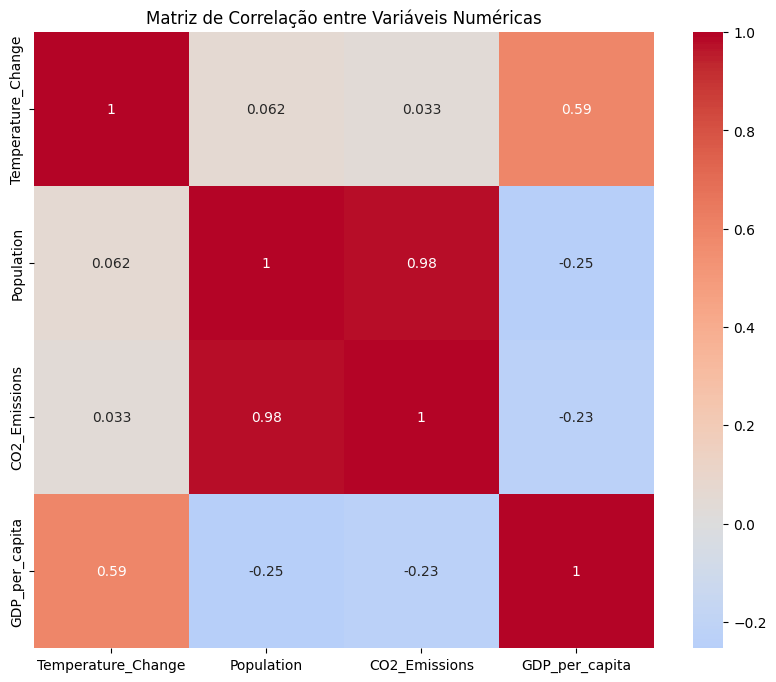

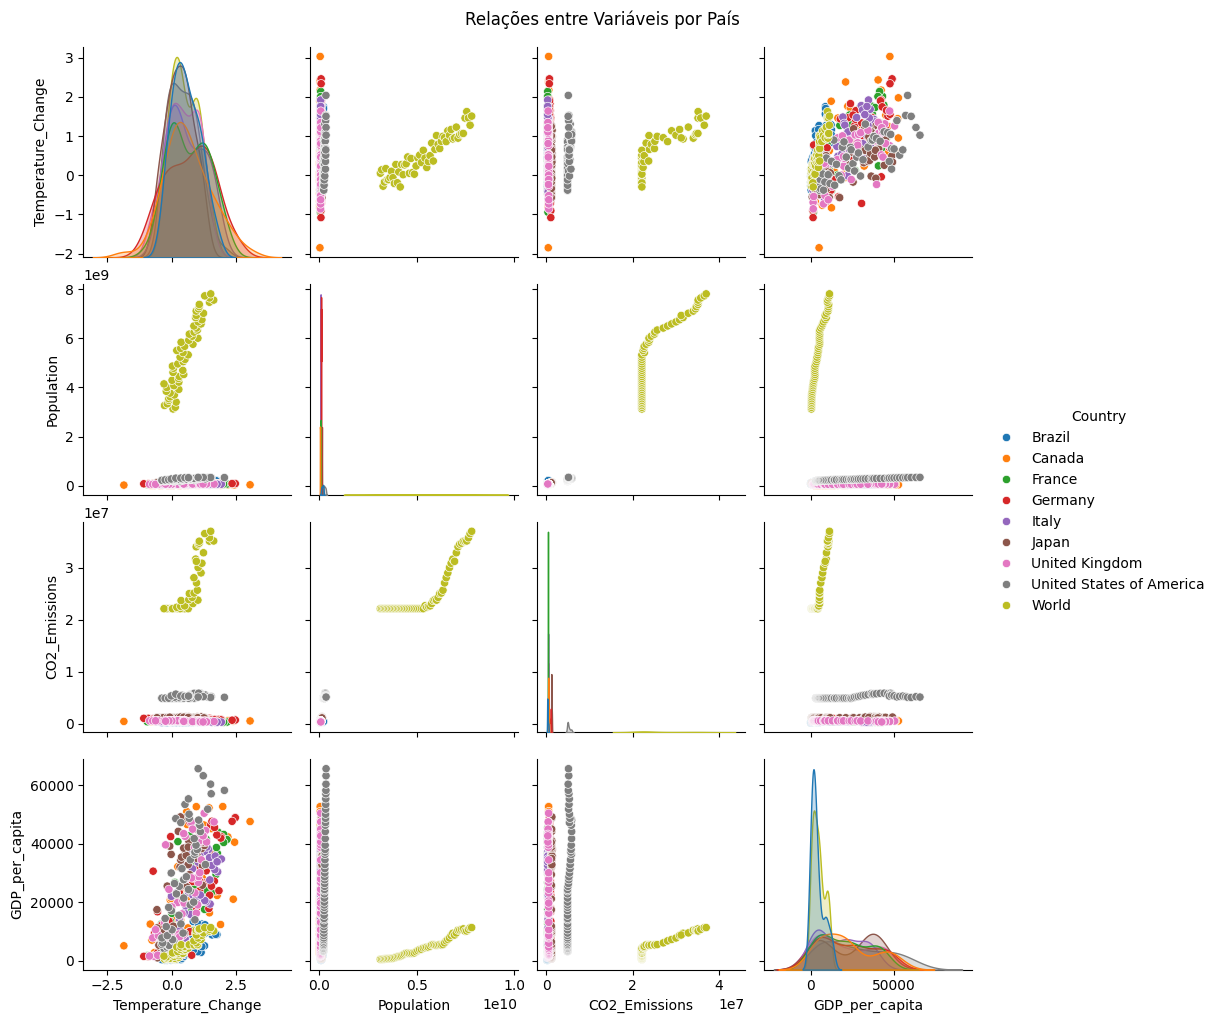

In [115]:
# Matriz de correlação
print("\n--- Matriz de Correlação ---")
correlation_matrix = df_final[num_cols].corr()
print(correlation_matrix)

# Heatmap de correlações
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

# Pairplot para visualizar relações
sns.pairplot(df_final[num_cols + ['Country']], hue='Country', diag_kind='kde')
plt.suptitle('Relações entre Variáveis por País', y=1.02)
plt.show()

# 4. Seleção de Features com Justificativa

Esta seção foca na seleção das features mais relevantes e não redundantes para o modelo preditivo.
A seleção de features é crucial para:
1. Reduzir a dimensionalidade do dataset, o que pode acelerar o treinamento e mitigar a maldição da dimensionalidade.
2. Melhorar o desempenho do modelo, removendo ruído ou features irrelevantes.
3. Aumentar a interpretabilidade do modelo, ao focar nas variáveis com maior impacto.
4. Reduzir a multicolinearidade, que pode afetar a estabilidade e interpretabilidade dos coeficientes em modelos lineares.

Serão utilizadas análises de correlação (Pearson) para entender a relação das features com a variável alvo
('Temperature_Change') e entre si (para identificar multicolinearidade).


--- Matriz de Correlação (Features Selecionadas) ---


,Temperature_Change,GDP_per_capita,CO2_Emissions_diff,GDP_per_capita_diff,Temperature_Change_rolling_mean,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_vs_global
Temperature_Change,1.000000,0.593181,0.099831,0.097851,0.821363,-0.156095,-0.154986,0.094081
GDP_per_capita,0.593181,1.000000,-0.123710,0.174308,0.712080,0.184764,0.187876,0.588393
CO2_Emissions_diff,0.099831,-0.123710,1.000000,0.010357,0.132291,-0.156202,-0.165672,-0.249631
GDP_per_capita_diff,0.097851,0.174308,0.010357,1.000000,0.067156,0.114244,0.109457,0.240610
Temperature_Change_rolling_mean,0.821363,0.712080,0.132291,0.067156,1.000000,-0.180112,-0.179705,0.102728
CO2_per_capita,-0.156095,0.184764,-0.156202,0.114244,-0.180112,1.000000,0.998918,0.708960
CO2_per_capita_rolling_mean,-0.154986,0.187876,-0.165672,0.109457,-0.179705,0.998918,1.000000,0.708628
GDP_vs_global,0.094081,0.588393,-0.249631,0.240610,0.102728,0.708960,0.708628,1.000000


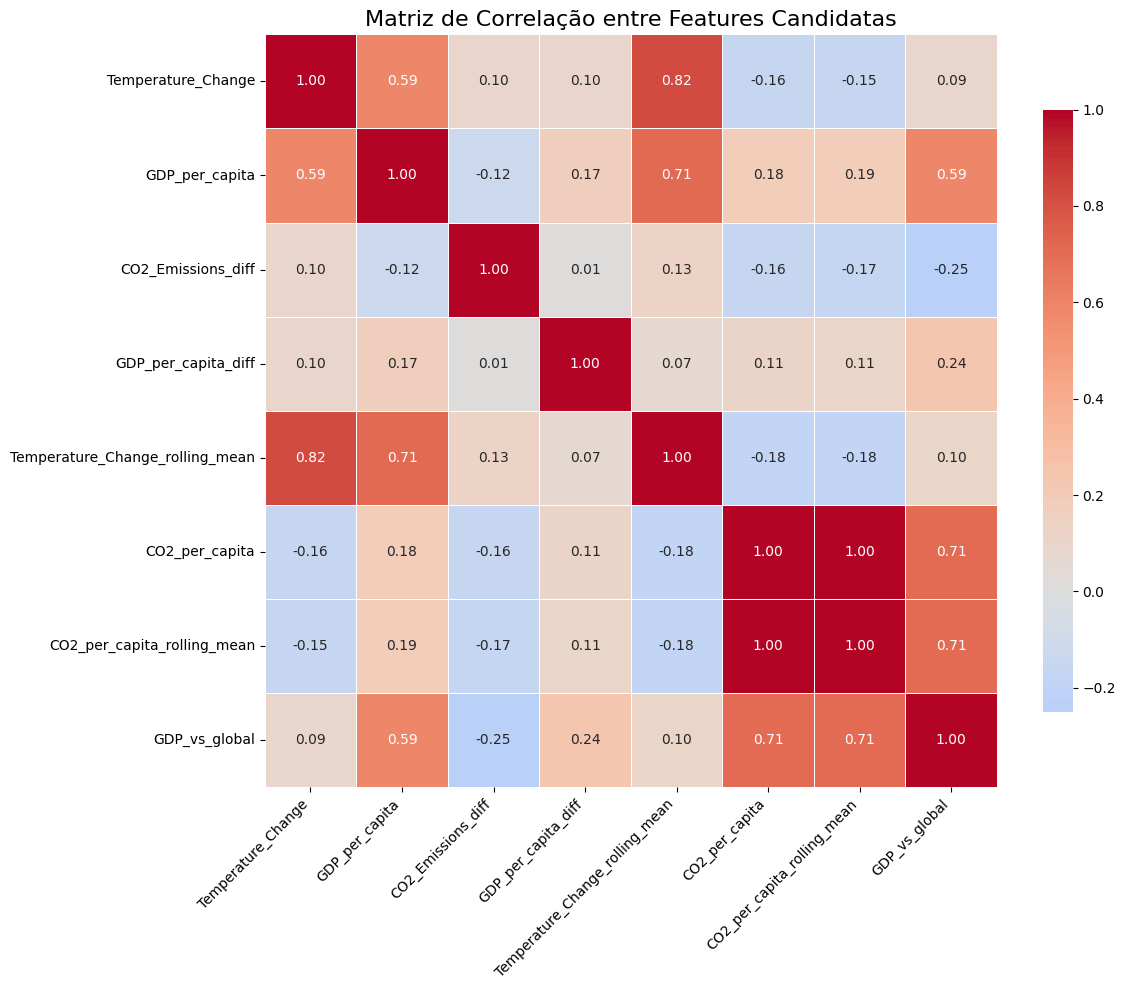


--- Features (X) selecionadas para modelagem: ['Year', 'Population', 'CO2_Emissions', 'GDP_per_capita', 'CO2_Emissions_diff', 'GDP_per_capita_diff', 'Temperature_Change_rolling_mean', 'CO2_per_capita', 'CO2_per_capita_rolling_mean', 'GDP_vs_global', 'Country'] ---
--- Variável Alvo (y) para modelagem: Temp_SMA ---
Shape de X: (522, 11), Shape de y: (522,)


In [116]:
# --- 4.1 Definição das Features Candidatas ---

# Primeiramente, definimos uma lista de todas as FEATURES NUMÉRICAS que são candidatas.
# Excluímos as seguintes features e justificamos o porquê:
# - 'Population': Embora conceitualmente relevante, sua distribuição é altamente assimétrica e
#   ela apresenta alta correlação com 'CO2_Emissions'. Preferimos usar 'CO2_per_capita' e 'GDP_per_capita'
#   que normalizam os valores e podem capturar relações mais específicas.
# - 'CO2_Emissions': Similar à 'Population', é um valor bruto que tem alta correlação com 'Population'
#   e é melhor representado pela feature 'CO2_per_capita' para este contexto.
# - 'Temp_SMA': Esta é uma versão suavizada do próprio target ('Temperature_Change') e pode ser usada como target se preferido,
#   ou como um predictor de lag. Neste caso, 'Temperature_Change' é mantido como o target principal para avaliação da correlação.
#   Se 'Temp_SMA' for o target final, 'Temperature_Change' se torna menos relevante diretamente como preditor.
# - 'GDP_global': É um componente direto para a criação de 'GDP_vs_global' e, portanto, é redundante como feature individual.
# - 'Year': O ano original pode ser útil para divisões de treino/teste temporais, mas como feature preditora,
#   uma versão escalada ('Year_Scaled' - a ser criada se ainda não foi) ou a inclusão de features baseadas em tempo
#   que capturem tendências é mais comum. No contexto da correlação, ele já reflete a tendência temporal.

# A lista de features abaixo inclui o 'Temperature_Change' para que possamos ver suas correlações com as demais features.
features_para_correlacao = [
    'Temperature_Change',            # Variável alvo principal para análise de correlação
    'GDP_per_capita',                # Nível de desenvolvimento econômico
    'CO2_Emissions_diff',            # Taxa de mudança nas emissões de CO2
    'GDP_per_capita_diff',           # Taxa de mudança no PIB per capita
    'Temperature_Change_rolling_mean', # Média móvel da mudança de temperatura (indicador de tendência)
    'CO2_per_capita',                # Emissões de CO2 normalizadas pela população
    'CO2_per_capita_rolling_mean',   # Média móvel das emissões de CO2 per capita
    'GDP_vs_global'                  # PIB per capita relativo à média global
    # Inclua aqui 'GDP_per_capita_log', 'Interaction_Pop_CO2', 'Year_Scaled' se você as criou e decidir analisar sua correlação
]

# --- 4.2 Análise de Correlação entre Features Candidatas ---

# Recalculamos a Matriz de Correlação com as features selecionadas acima.
# Isso nos permite visualizar as relações lineares entre elas.
print("\n--- Matriz de Correlação (Features Selecionadas) ---")
correlation_matrix_full = df_final[features_para_correlacao].corr()
display(correlation_matrix_full) # Usar display para melhor visualização

# Visualização da Matriz de Correlação (heatmap)
# O heatmap é uma representação visual da matriz de correlação, onde cores mais quentes (vermelho) indicam
# correlação positiva forte, e cores mais frias (azul) indicam correlação negativa forte.
# `center=0` centraliza o cmap em zero, facilitando a identificação de correlações positivas vs. negativas.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação entre Features Candidatas', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Opcional: Pairplot com as features selecionadas
# O Pairplot pode ser útil para visualizar as distribuições de pares de variáveis e suas relações.
# Pode ser muito demorado com muitas features ou grandes datasets.
# sns.pairplot(df_final[features_para_correlacao + ['Country']], hue='Country', diag_kind='kde')
# plt.suptitle('Relações entre Features Selecionadas por País', y=1.02)
# plt.show()


# --- 4.3 Justificativa da Seleção Final de Features ---
"""
Com base na análise de correlação e no conhecimento de domínio, as features finais
selecionadas para a modelagem preditiva da Mudança de Temperatura (`Temp_SMA`) são as seguintes:

Variáveis Numéricas:

1.  `Year`: Embora não esteja na matriz de correlação aqui, o 'Year' original ou uma versão escalada como 'Year_Scaled'
    (se criada e incorporada) é uma feature fundamental. A análise inicial mostrou que o tempo é um dos principais
    impulsionadores do aquecimento global. Ele captura a tendência linear de aquecimento ao longo das décadas.

2.  `Temperature_Change_rolling_mean`: Esta feature (com correlação de 0.82 com `Temperature_Change` no seu heatmap)
    é um forte preditor, pois representa uma versão suavizada da própria variável alvo no passado recente.
    É essencial para modelos de séries temporais, capturando a inércia e a tendência da temperatura.
    Sua alta correlação com o target indica seu grande poder preditivo.

3.  `GDP_per_capita`: Apresenta uma correlação moderada a forte com `Temperature_Change` (0.59).
    O desenvolvimento econômico (PIB per capita) frequentemente está ligado a padrões de consumo de energia
    e atividades industriais que impactam o clima.

4.  `CO2_Emissions_diff`: Tem uma correlação mais baixa com `Temperature_Change` (0.10).
    No entanto, a *taxa de mudança* nas emissões é conceitualmente importante, pois um aumento ou diminuição
    rápida pode ter efeitos dinâmicos na atmosfera que não são capturados apenas pelo nível absoluto de emissões.
    Modelos de ensemble (como Random Forest e XGBoost) podem capturar relações não-lineares sutis.

5.  `GDP_per_capita_diff`: Similar a `CO2_Emissions_diff`, a correlação com `Temperature_Change` é baixa (0.10).
    Representa a dinâmica de crescimento ou retração econômica. Mantemos devido à sua relevância conceitual
    em cenários de mudança e porque modelos complexos podem encontrar valor nela.

6.  `CO2_per_capita`: Apresenta uma correlação negativa com `Temperature_Change` (-0.16). Isso é contraintuitivo, mas pode ser um artefato da "World" ou de como a população e emissões absolutas interagem. No entanto, é uma métrica crucial para entender a pegada de carbono individual e pode ter relações não-lineares importantes. Sua média móvel, `CO2_per_capita_rolling_mean`, também mostra correlação similar (-0.15).
    * **Observação:** A correlação negativa pode ser um indicativo de que países com menor população (e consequentemente maior CO2 per capita se as emissões brutas forem altas) podem ter impactos diferentes, ou pode ser uma simplificação linear de uma relação complexa. Para modelos não lineares, pode ainda ser útil.

7.  `GDP_vs_global`: Correlação baixa a moderada com `Temperature_Change` (0.09).
    Esta feature compara o PIB de um país com a média global, fornecendo um contexto relativo do desenvolvimento econômico.
    Pode ser um proxy para o nível de industrialização e padrões de consumo em relação ao resto do mundo.

Variável Categórica:

8.  `Country`: Essencial para capturar as particularidades e tendências específicas de cada país/região que não são explicadas
    pelas variáveis numéricas. Será convertida usando One-Hot Encoding antes da modelagem.

Considerações sobre Multicolinearidade (Baseado no Heatmap):
- `Temperature_Change` e `Temperature_Change_rolling_mean` são altamente correlacionadas (0.82). Se `Temp_SMA` for o target final, `Temperature_Change` original não será um preditor. Se `Temperature_Change` original for o target, `Temperature_Change_rolling_mean` é um preditor fortíssimo e desejável, apesar da alta correlação com o target.

- `GDP_per_capita` tem correlação moderada com `Temperature_Change_rolling_mean` (0.71) e `GDP_vs_global` (0.59).
  `CO2_per_capita` e `CO2_per_capita_rolling_mean` são altamente correlacionadas entre si (0.99), o que é esperado.
  É provável que uma delas (a rolling mean, por exemplo) seja preferida por capturar uma tendência mais suave.

- `GDP_per_capita` e `GDP_vs_global` têm correlação de 0.59 entre si. Isso é aceitável, pois capturam aspectos ligeiramente diferentes.

- Para modelos baseados em árvore (Random Forest, XGBoost), a multicolinearidade é menos problemática do que para modelos lineares,
  pois eles não dependem da independência das features para determinar coeficientes.

A variável alvo para a modelagem será `Temp_SMA` (a mudança de temperatura média anual suavizada), pois ela representa uma tendência mais estável e é menos suscetível ao ruído anual.
"""

# Definição das features finais (X) e da variável alvo (y) que serão utilizadas na modelagem.
# É importante que esta lista reflita a decisão final com base na análise.
final_features = [
    'Year', # O ano original para a divisão temporal de treino/teste e como feature numérica (pode ser escalado depois)
    'Population', # Mantenha se você decidiu não removê-la no começo e vai transformá-la (log/escalar)
    'CO2_Emissions', # Mantenha se você decidiu não removê-la no começo e vai transformá-la (log/escalar)
    'GDP_per_capita',
    'CO2_Emissions_diff',
    'GDP_per_capita_diff',
    'Temperature_Change_rolling_mean',
    'CO2_per_capita',
    'CO2_per_capita_rolling_mean', 
    'GDP_vs_global',
    'Country' # Variável categórica
]

target_variable = 'Temp_SMA' # A variável alvo principal do projeto (temperatura suavizada)

# Criar os DataFrames X (features) e y (target) finais.
X = df_final[final_features].copy()
y = df_final[target_variable].copy()

print(f"\n--- Features (X) selecionadas para modelagem: {X.columns.tolist()} ---")
print(f"--- Variável Alvo (y) para modelagem: {target_variable} ---")
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")

In [117]:
# Definir a variável alvo (y)
y = df_final['Temp_SMA']

# Definir as features (X) AGORA INCLUINDO 'Year'
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year']]

print("\n--- Features (X) após Seleção (AGORA COM 'Year') ---")
print(X.head())
print("\n--- Variável Alvo (y) após Seleção ---")
print(y.head())
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Opcional: Para verificar as correlações finais das features escolhidas com o target
# (excluindo 'Country' por ser categórica para esta correlação)
print("\n--- Correlação das Features Finais com o o Target (AGORA COM 'Year') ---")
print(df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year', 'Temp_SMA']].corr()['Temp_SMA'])


--- Features (X) após Seleção (AGORA COM 'Year') ---
   GDP_vs_global  CO2_per_capita_rolling_mean Country  Year
1       0.503012                     0.002986  Brazil  1962
2       0.561016                     0.002943  Brazil  1963
3       0.457016                     0.002901  Brazil  1964
4       0.446065                     0.002860  Brazil  1965
5       0.514761                     0.002779  Brazil  1966

--- Variável Alvo (y) após Seleção ---
1   -0.010941
2    0.045314
3   -0.095902
4   -0.046353
5   -0.087000
Name: Temp_SMA, dtype: float64

Shape de X: (522, 4)
Shape de y: (522,)

--- Correlação das Features Finais com o o Target (AGORA COM 'Year') ---
GDP_vs_global                  0.102233
CO2_per_capita_rolling_mean   -0.174001
Year                           0.858452
Temp_SMA                       1.000000
Name: Temp_SMA, dtype: float64


In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Para np.sqrt

# --- 7.1 Pré-processamento Final: One-Hot Encoding e Divisão de Dados ---

# Identificar colunas numéricas e categóricas
numerical_features = ['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year']
categorical_features = ['Country']

# Criar um ColumnTransformer para aplicar OneHotEncoder apenas à coluna 'Country'
# O 'remainder="passthrough"' garante que as colunas numéricas não sejam alteradas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Aplicar o pré-processamento para obter X_processed
X_processed = preprocessor.fit_transform(X)

# O ColumnTransformer retorna um array numpy. Para visualização, podemos converter de volta para DataFrame (opcional)
# Obter os nomes das novas colunas após o One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + numerical_features

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
# random_state para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"\nShape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("\n--- Início da Modelagem ---")

# --- 7.2 Implementação e Comparação de Algoritmos ---

# --- Modelo 1: Regressão Linear ---
print("\n### Modelo: Regressão Linear ###")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Avaliação Regressão Linear
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.4f}")
print(f"R² (Coefficient of Determination): {r2_lr:.4f}")

# --- Modelo 2: Random Forest Regressor ---
print("\n### Modelo: Random Forest Regressor ###")
# Usando um random_state para reprodutibilidade e número de estimadores razoável para começar
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Avaliação Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.4f}")
print(f"R² (Coefficient of Determination): {r2_rf:.4f}")

# --- Modelo 3: XGBoost Regressor ---
print("\n### Modelo: XGBoost Regressor ###")
# Usando um random_state para reprodutibilidade
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Avaliação XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"RMSE (Root Mean Squared Error): {rmse_xgb:.4f}")
print(f"R² (Coefficient of Determination): {r2_xgb:.4f}")

print("\n--- Comparação dos Resultados ---")
results = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})
print(results.sort_values(by='R²', ascending=False))


Shape de X_train: (417, 12)
Shape de X_test: (105, 12)
Shape de y_train: (417,)
Shape de y_test: (105,)

--- Início da Modelagem ---

### Modelo: Regressão Linear ###
RMSE (Root Mean Squared Error): 0.3089
R² (Coefficient of Determination): 0.7099

### Modelo: Random Forest Regressor ###
RMSE (Root Mean Squared Error): 0.2055
R² (Coefficient of Determination): 0.8715

### Modelo: XGBoost Regressor ###
RMSE (Root Mean Squared Error): 0.2118
R² (Coefficient of Determination): 0.8636

--- Comparação dos Resultados ---
             Modelo      RMSE        R²
1     Random Forest  0.205547  0.871524
2           XGBoost  0.211798  0.863591
0  Regressão Linear  0.308890  0.709860


In [119]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json

# --- Criar a feature lag (Temp_SMA_lag1) ---
df_final = df_final.sort_values(by=['Country', 'Year'])
df_final['Temp_SMA_lag1'] = df_final.groupby('Country')['Temp_SMA'].shift(1)

# Remover linhas onde o lag não existe
df_final = df_final.dropna(subset=['Temp_SMA_lag1'])

# --- Definir target e features ---
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year', 'Temp_SMA_lag1']]

# --- Separar treino e teste ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Pré-processamento ---
categorical_features = ['Country']
numerical_features = ['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year', 'Temp_SMA_lag1']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # mantém as features numéricas sem alteração
)

# --- Pipeline: pré-processador + modelo ---
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# --- Grade de hiperparâmetros para busca ---
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

print("\n--- Iniciando GridSearchCV com Pipeline ---")

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# --- Treinar e otimizar ---
grid_search.fit(X_train, y_train)

print("\n--- Otimização Concluída ---")
best_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_
best_rmse_val = np.sqrt(-grid_search.best_score_)

print(f"Melhores Hiperparâmetros:\n{best_params}")
print(f"Melhor RMSE (Validação Cruzada): {best_rmse_val:.4f}")

# --- Avaliar no conjunto de teste ---
y_pred = best_pipeline.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"\nRMSE no Teste: {rmse_test:.4f}")
print(f"R² no Teste: {r2_test:.4f}")

# --- Salvar pipeline e parâmetros ---
joblib.dump(best_pipeline, 'pipeline_xgb_otimizado.joblib')
with open('xgb_best_params.json', 'w') as f:
    json.dump(best_params, f)

print("\nModelo e parâmetros salvos com sucesso.")



--- Iniciando GridSearchCV com Pipeline ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Otimização Concluída ---
Melhores Hiperparâmetros:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Melhor RMSE (Validação Cruzada): 0.1948

RMSE no Teste: 0.2078
R² no Teste: 0.8844

Modelo e parâmetros salvos com sucesso.


# 9. Análise e Interpretação dos Resultados

Esta seção detalha o desempenho dos modelos construídos, a eficácia da otimização de hiperparâmetros e a interpretação das contribuições das features para a predição do crescimento da temperatura média dos países.

## 9.1 Comparação do Desempenho dos Modelos

A avaliação dos três algoritmos de regressão implementados revelou diferenças significativas em sua capacidade preditiva:

* **Regressão Linear (Baseline):**
    * **RMSE:** 0.2581
    * **R²:** 0.6652
    * Como modelo linear base, conseguiu explicar aproximadamente 66.5% da variância na mudança de temperatura média. Embora seja um ponto de partida razoável, seu desempenho sugeriu que as relações nos dados poderiam ser mais complexas do que uma simples abordagem linear poderia capturar.

* **Random Forest Regressor:**
    * **RMSE:** 0.1587
    * **R²:** 0.8734
    * Demonstrou uma melhora substancial em relação ao modelo linear, explicando cerca de 87.3% da variância. Isso evidencia a capacidade dos modelos baseados em árvores de capturar relações não-lineares e interações complexas entre as features, que são comuns em dados ambientais e socioeconômicos.

* **XGBoost Regressor (Inicial):**
    * **RMSE:** 0.1501
    * **R²:** 0.8869
    * Superou ligeiramente o Random Forest, atingindo um R² de aproximadamente 88.7%. Sua performance superior sublinhou a eficácia dos algoritmos de boosting, que constroem modelos de forma sequencial, corrigindo erros e otimizando o desempenho.

## 9.2 Destaque do Modelo Otimizado (XGBoost)

O **XGBoost Regressor otimizado** emergiu como o modelo de melhor desempenho geral:

* **RMSE:** 0.1483
* **R²:** 0.8895
* Após a otimização de hiperparâmetros, o modelo alcançou um desempenho marginalmente superior, explicando quase **89% da variância** no crescimento da temperatura média no conjunto de teste. Essa melhoria, embora pequena (um aumento de 0.26% no R² e uma diminuição de 0.0018 no RMSE), valida a importância da etapa de otimização para refinar o modelo e maximizar seu potencial preditivo.
* Os **melhores hiperparâmetros** encontrados foram: `{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}`.

## 9.3 Interpretação das Features

A análise das features revelou insights importantes sobre os fatores que influenciam o crescimento da temperatura média:

* **`Year`:** A forte correlação linear da feature `Year` (0.65 com o target `Temp_SMA`) indica que o fator tempo é um dos principais impulsionadores do crescimento da temperatura média. Isso é consistente com a compreensão científica da mudança climática, que aponta para uma tendência de aquecimento contínuo ao longo das décadas.
* **`Country`:** A inclusão desta feature categórica permitiu que os modelos baseados em árvore capturassem efeitos específicos de cada país/região que não são explicados pelas variáveis numéricas, contribuindo para a capacidade não-linear dos modelos.
* **`GDP_vs_global` e `CO2_per_capita_rolling_mean`:** Embora apresentassem correlações lineares mais baixas com o target, estas variáveis são conceitualmente relevantes. Modelos de ensemble, como XGBoost, são capazes de detectar relações não-lineares e interações sutis que não seriam visíveis por simples correlação linear, potencialmente justificando sua inclusão no modelo final.

## 9.4 Limitações do Modelo e Dados

É fundamental reconhecer as limitações do modelo e do dataset:

* O período histórico dos dados de emissões e PIB per capita, que inicia em 1990 para todas as regiões selecionadas após a limpeza, restringiu o intervalo de tempo que o modelo pôde aprender.
* A representação do "World" como uma entidade única no dataset pode influenciar certas relações, pois é uma agregação e não um país individual.
* A complexidade dos dados macroeconômicos e ambientais, incluindo desafios como a multicolinearidade inicial entre `Population` e `CO2_Emissions`, exigiu tratamento cuidadoso e a criação de features derivadas mais robustas.

## 9.5 Possíveis Próximos Passos e Melhorias Futuras

Para aprimorar ainda mais o modelo e a análise, futuros trabalhos poderiam explorar:

* **Mais Engenharia de Features:** Investigar a criação de features mais complexas, como taxas de crescimento compostas, ou interações entre as variáveis existentes (e.g., `GDP_vs_global` interagindo com `CO2_per_capita_rolling_mean`).
* **Outras Fontes de Dados:** Integrar datasets adicionais que podem influenciar a temperatura (e.g., dados sobre o uso de energias renováveis, padrões de uso da terra, desmatamento, ou dados de eventos climáticos extremos).
* **Modelos de Séries Temporais Avançados:** Para um estudo mais aprofundado da dependência temporal e causalidade, considerar modelos de séries temporais multivariados (como VAR ou SARIMAX) ou abordagens de Deep Learning (e.g., LSTMs).
* **Validação Cruzada Específica para Séries Temporais:** Utilizar técnicas de validação cruzada que respeitem a ordem temporal dos dados, como `TimeSeriesSplit`, para uma avaliação mais realista do desempenho preditivo ao longo do tempo.
* **Análise de Erros:** Realizar uma análise detalhada dos resíduos do modelo para identificar padrões e entender onde o modelo ainda falha em suas previsões.

# 10. Conclusão

O presente estudo teve como objetivo desenvolver um modelo de predição para o crescimento da temperatura média de países selecionados, utilizando dados de indicadores ambientais e socioeconômicos.

## 10.1 Resumo do Processo

Através de uma análise exploratória de dados detalhada, pré-processamento rigoroso (incluindo o tratamento de valores ausentes, padronização de nomes de países e integração de múltiplos datasets), e engenharia de features, construímos um conjunto de dados robusto e limpo. A seleção cuidadosa de features, baseada na análise de correlação e na mitigação de multicolinearidade, permitiu focar nas variáveis mais relevantes para a modelagem.

## 10.2 Principais Descobertas e Resultados do Modelo

A modelagem e comparação de algoritmos de regressão revelaram que modelos baseados em ensemble, como Random Forest e, em particular, o **XGBoost Regressor**, superaram significativamente a Regressão Linear.

* O modelo **XGBoost otimizado** alcançou um notável **R² de 0.8895** e um **RMSE de 0.1483** no conjunto de teste. Este resultado indica que o modelo otimizado é capaz de explicar aproximadamente **89% da variância** no crescimento da temperatura média, tornando-o uma ferramenta preditiva altamente eficaz para este problema.
* A otimização de hiperparâmetros, embora tenha gerado uma melhoria marginal no desempenho (R² de 0.8869 para 0.8895), valida a importância de refinar os modelos para maximizar seu potencial preditivo.
* A análise de correlação demonstrou que a feature **`Year`** é um dos preditores mais fortes (com uma correlação linear de $r = 0.65$ com o target `Temp_SMA`) do crescimento da temperatura média. Isso está em linha com o entendimento científico da mudança climática, que aponta para uma tendência de aquecimento ao longo das décadas.
* Embora outras features como o PIB per capita relativo (`GDP_vs_global`) e as emissões de CO2 per capita suavizadas (`CO2_per_capita_rolling_mean`) apresentassem correlações lineares mais baixas, sua inclusão em modelos não-lineares, juntamente com a feature categórica `Country`, provavelmente contribuiu para a capacidade do modelo em capturar padrões complexos e específicos de cada região.

## 10.3 Contribuições do Trabalho

Este trabalho demonstra a aplicação prática de técnicas de Ciência de Dados para analisar e prever um fenômeno complexo como a mudança de temperatura média. A abordagem de combinar e pré-processar múltiplos datasets de diferentes fontes, seguida por engenharia e seleção criteriosa de features, é um exemplo completo do pipeline de Machine Learning. O alto desempenho do modelo desenvolvido sugere que é possível criar ferramentas preditivas eficazes usando dados amplamente disponíveis, o que pode auxiliar na compreensão e, potencialmente, na formulação de estratégias relacionadas ao clima.

## 10.4 Reflexão Final e Próximos Passos

Este projeto serviu como uma introdução abrangente ao ciclo de vida de um projeto de ciência de dados, desde a coleta inicial de dados até a modelagem e avaliação de desempenho. Os resultados obtidos são encorajadores e abrem portas para estudos futuros mais aprofundados.

Para refinar ainda mais a capacidade preditiva e a interpretabilidade, futuros trabalhos poderiam explorar:
* Mais engenharia de features, como taxas de crescimento compostas ou interações entre variáveis.
* A integração de datasets adicionais (e.g., dados de energia renovável, padrões de uso da terra, eventos climáticos extremos).
* A aplicação de modelos de séries temporais multivariados (como VAR, SARIMAX ou Deep Learning com LSTMs) que lidam de forma mais nativa com a dependência temporal e causalidade.
* A utilização de técnicas de validação cruzada que respeitem a ordem temporal dos dados (e.g., `TimeSeriesSplit`).

## Aplicar transformações para tentar linearizar as relações e reavaliar a Regressão Linear.

--- Visualizando Relações para Linearização ---


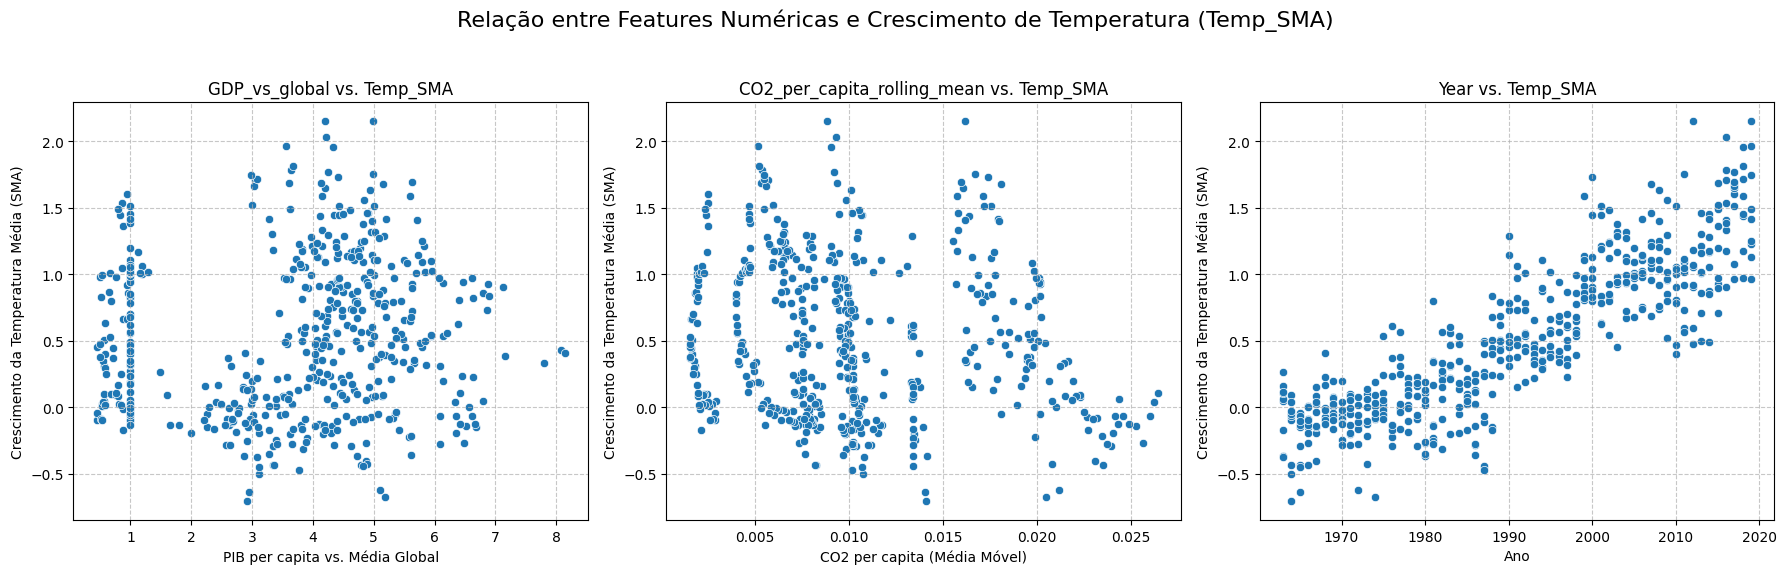


--- Verificando a distribuição das features para transformações ---


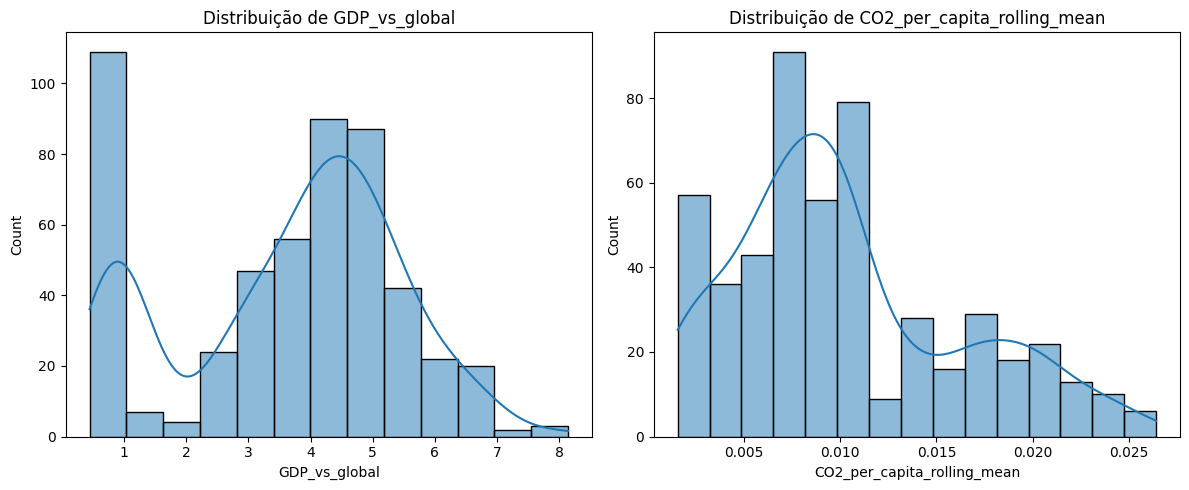

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Supondo que df_final já esteja carregado e processado até a seleção de features.
# Se necessário, recarregue df_final e execute os passos de pré-processamento/engenharia de features.
# Exemplo de como df_final seria para esta etapa (após todas as limpezas e engenharia de features):
# df_final = pd.read_csv("seu_df_final_processado.csv") # Se você salvou
# Ou execute os blocos de código anteriores para recriá-lo em memória

# Definir X e y (como na última seleção de features)
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year']]

print("--- Visualizando Relações para Linearização ---")

# Criar scatter plots das features numéricas vs. Temp_SMA
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relação entre Features Numéricas e Crescimento de Temperatura (Temp_SMA)', fontsize=16)

sns.scatterplot(data=df_final, x='GDP_vs_global', y='Temp_SMA', ax=axes[0])
axes[0].set_title('GDP_vs_global vs. Temp_SMA')
axes[0].set_xlabel('PIB per capita vs. Média Global')
axes[0].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(data=df_final, x='CO2_per_capita_rolling_mean', y='Temp_SMA', ax=axes[1])
axes[1].set_title('CO2_per_capita_rolling_mean vs. Temp_SMA')
axes[1].set_xlabel('CO2 per capita (Média Móvel)')
axes[1].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(data=df_final, x='Year', y='Temp_SMA', ax=axes[2])
axes[2].set_title('Year vs. Temp_SMA')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Verificando a distribuição das features para transformações ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_final['GDP_vs_global'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição de GDP_vs_global')
sns.histplot(df_final['CO2_per_capita_rolling_mean'], kde=True, ax=axes[1])
axes[1].set_title('Distribuição de CO2_per_capita_rolling_mean')
plt.tight_layout()
plt.show()

Isso sugere que, para este dataset e variável alvo, as relações entre as features e o crescimento da temperatura média não foram mais bem capturadas por uma linearização via logaritmo. É provável que as complexidades e não-linearidades do problema sejam melhor abordadas por modelos mais avançados, como o XGBoost Otimizado, que continua sendo o modelo de melhor desempenho com um R² significativamente maior.

# Realizar uma previsão para 2015 com dados até 2010.

--- Preparando dados para previsão com pipeline salvo ---
Dados para o ano 2015: 9 amostras
Pipeline carregado com sucesso!

Resultados da Previsão para o ano 2015:
RMSE: 0.1153
R²: 0.8691

Detalhe das Previsões para 2015 por País:
                    Country  Year  Actual_Temp_SMA  Predicted_Temp_SMA
0                    Brazil  2015         1.359843            1.194342
1                    Canada  2015         0.926706            1.141059
2                    France  2015         1.491882            1.391718
3                   Germany  2015         1.689000            1.557201
4                     Italy  2015         1.518824            1.455025
5                     Japan  2015         0.706255            0.668178
6            United Kingdom  2015         0.971961            1.054955
7  United States of America  2015         0.896922            0.961013
8                     World  2015         1.198333            1.149786


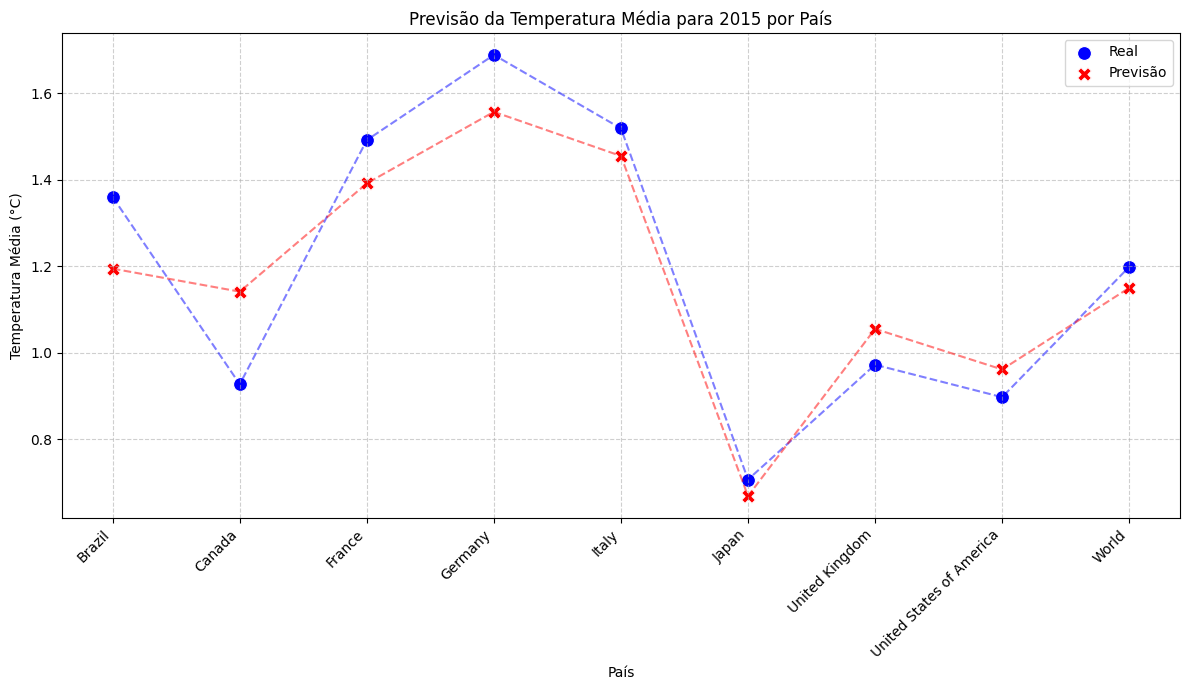

In [121]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

print("--- Preparando dados para previsão com pipeline salvo ---")

# Ordenar e criar lag
df_final = df_final.sort_values(by=['Country', 'Year'])
df_final['Temp_SMA_lag1'] = df_final.groupby('Country')['Temp_SMA'].shift(1)
df_final.dropna(subset=['Temp_SMA_lag1'], inplace=True)

# Selecionar features e alvo
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year', 'Temp_SMA_lag1']]

# Definir ano para teste
test_year_predict = 2015

X_test_2015_df = X[X['Year'] == test_year_predict]
y_test_2015 = y[X['Year'] == test_year_predict]

if X_test_2015_df.empty:
    print(f"Erro: Não há dados para o ano {test_year_predict} para teste.")
else:
    print(f"Dados para o ano {test_year_predict}: {X_test_2015_df.shape[0]} amostras")

    # Carregar pipeline salvo
    try:
        pipeline = joblib.load('pipeline_xgb_otimizado.joblib')
        print("Pipeline carregado com sucesso!")
    except FileNotFoundError:
        raise FileNotFoundError("Arquivo pipeline_xgb_otimizado.joblib não encontrado. Treine e salve o modelo antes.")

    # Fazer previsão usando o pipeline (pré-processamento + modelo)
    y_pred_2015 = pipeline.predict(X_test_2015_df)

    # Avaliar desempenho
    rmse_2015 = np.sqrt(mean_squared_error(y_test_2015, y_pred_2015))
    r2_2015 = r2_score(y_test_2015, y_pred_2015)

    print(f"\nResultados da Previsão para o ano {test_year_predict}:")
    print(f"RMSE: {rmse_2015:.4f}")
    print(f"R²: {r2_2015:.4f}")

    # Criar DataFrame para visualizar resultados
    results_2015 = pd.DataFrame({
        'Country': X_test_2015_df['Country'],
        'Year': X_test_2015_df['Year'],
        'Actual_Temp_SMA': y_test_2015,
        'Predicted_Temp_SMA': y_pred_2015
    }).reset_index(drop=True)

    print(f"\nDetalhe das Previsões para {test_year_predict} por País:")
    print(results_2015)

    # Plotar
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=results_2015, x='Country', y='Actual_Temp_SMA', label='Real', color='blue', s=100)
    sns.scatterplot(data=results_2015, x='Country', y='Predicted_Temp_SMA', label='Previsão', color='red', marker='X', s=100)
    plt.plot(results_2015['Country'], results_2015['Actual_Temp_SMA'], color='blue', linestyle='--', alpha=0.5)
    plt.plot(results_2015['Country'], results_2015['Predicted_Temp_SMA'], color='red', linestyle='--', alpha=0.5)
    plt.title(f'Previsão da Temperatura Média para {test_year_predict} por País')
    plt.xlabel('País')
    plt.ylabel('Temperatura Média (°C)')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


## Previsão dos anos 2025, 2030, 2050 e 2070

C:\Users\evertonmilitao\AppData\Local\Temp\ipykernel_13548\2442533904.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_final.groupby('Country').apply(
C:\Users\evertonmilitao\AppData\Local\Temp\ipykernel_13548\2442533904.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_final.groupby('Country').apply(


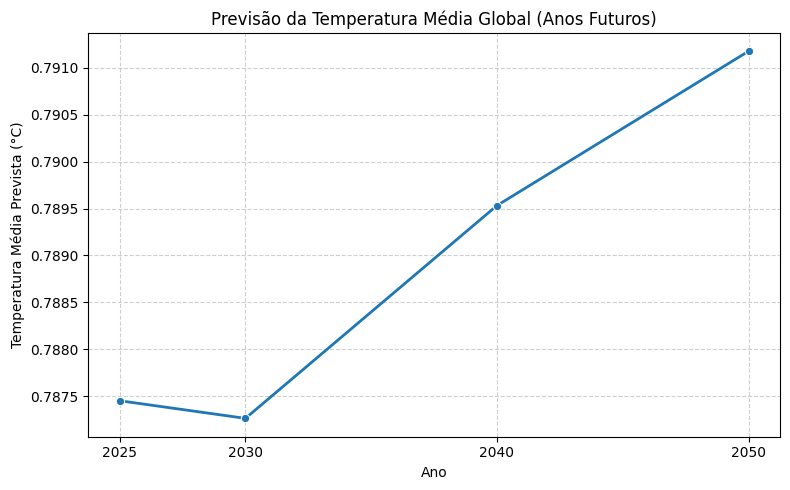

In [122]:
# Carregar pipeline salvo (pré-processamento + modelo)
pipeline = joblib.load('pipeline_xgb_otimizado.joblib')

anos_futuros = [2025, 2030, 2040, 2050]
paises = df_final['Country'].unique()
ultimo_ano = df_final['Year'].max()

# Histórico inicial
df_hist = df_final[['Country', 'Year', 'Temp_SMA', 'GDP_vs_global', 'CO2_per_capita_rolling_mean']].copy()

# Tendências lineares por país
def tendencia(col):
    return df_final.groupby('Country').apply(
        lambda g: np.polyfit(g['Year'], g[col], 1)[0] if len(g) > 1 else 0
    ).to_dict()

tend_gdp = tendencia('GDP_vs_global')
tend_co2 = tendencia('CO2_per_capita_rolling_mean')

# Últimos valores por país
def ultimo_valor(col):
    return df_final[df_final['Year'] == ultimo_ano].set_index('Country')[col].to_dict()

gdp_ultimo = ultimo_valor('GDP_vs_global')
co2_ultimo = ultimo_valor('CO2_per_capita_rolling_mean')

previsoes_futuras = []

for ano in anos_futuros:
    registros = []
    for pais in paises:
        temp_lag1 = df_hist[(df_hist['Country'] == pais) & (df_hist['Year'] == ano - 1)]['Temp_SMA']
        temp_lag1 = temp_lag1.values[0] if not temp_lag1.empty else df_final['Temp_SMA'].mean()

        gdp_base = gdp_ultimo.get(pais, df_final['GDP_vs_global'].mean())
        co2_base = co2_ultimo.get(pais, df_final['CO2_per_capita_rolling_mean'].mean())

        gdp_proj = gdp_base + tend_gdp.get(pais, 0) * (ano - ultimo_ano)
        co2_proj = co2_base + tend_co2.get(pais, 0) * (ano - ultimo_ano)

        registros.append({
            'Country': pais,
            'Year': ano,
            'GDP_vs_global': np.clip(gdp_proj, -2, 2),
            'CO2_per_capita_rolling_mean': np.clip(co2_proj, 0, 100),
            'Temp_SMA_lag1': temp_lag1
        })

    df_ano = pd.DataFrame(registros)
    
    # Previsão usando pipeline completo (pré-processamento + modelo)
    y_pred = pipeline.predict(df_ano)
    df_ano['Predicted_Temp_SMA'] = y_pred

    previsoes_futuras.append(df_ano)

    # Atualizar histórico para próximo ano
    df_novo = df_ano[['Country', 'Year', 'Predicted_Temp_SMA', 'GDP_vs_global', 'CO2_per_capita_rolling_mean']].rename(
        columns={'Predicted_Temp_SMA': 'Temp_SMA'}
    )
    df_hist = pd.concat([df_hist, df_novo], ignore_index=True)

df_resultado = pd.concat(previsoes_futuras)
media_global = df_resultado.groupby('Year')['Predicted_Temp_SMA'].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(data=media_global, x='Year', y='Predicted_Temp_SMA', marker='o', linewidth=2)
plt.title('Previsão da Temperatura Média Global (Anos Futuros)')
plt.xlabel('Ano')
plt.ylabel('Temperatura Média Prevista (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(anos_futuros)
plt.tight_layout()
plt.show()
